# **Probabilistic Machine-Learning (PML) Data Analysis**

## Data Analysis Notebook for all calculated stock features

### Covers 26 feature categories from 63 calc_* functions:

  1. Valuation Ratios (4 functions)
  2. Momentum (2 functions)
  3. Technical Analysis (1 function)
  4. Profitability (4 functions)
  5. Earnings (6 functions)
  6. Growth (5 functions) - includes Revenue Estimate Consensus
  7. Quality & Risk (5 functions)
  8. Leverage & Liquidity (6 functions)
  9. Analyst Sentiment (3 functions) - includes Price Target Achievement
  10. Dividends (3 functions)
  11. Employment (2 functions)
  12. Cash Flow (5 functions) - includes FCF Growth Estimates
  13. Temporal (2 functions)
  14. Balance Sheet (3 functions)
  15. Cost Structure (3 functions)
  16. Composite Scores (2 functions)
  17. Unusual Items (1 function)
  18. Volatility Surface (1 function)
  19. Tax Rate Features (1 function)
  20. OpEx Temporal (1 function)
  21. Asset Sale Features (1 function)
  22. FCF Estimate Curve (1 function)
  23. Dividend History (1 function)
  24. Investment Income Temporal (1 function)
  25. Share Dilution Tracking (1 function)
  26. Forward Consensus (1 function)
  27. Price Target Achievement (1 function)
  28. Size & Liquidity (1 function)
  29. FCF Growth Estimates (1 function)

Direct reference columns include: Enhancement 1 (17 cols), Enhancement 6 (6 cols),

## 1. Setup & Data Loading

In [1]:
# ── Configure PyTensor to use Python-only mode (must run before any PyMC import) ──
# On Windows with MSVC-built CPython 3.14, MinGW g++ cannot reliably link against
# python314.dll due to ABI incompatibility.  Setting cxx="" disables C compilation
# entirely and uses PyTensor's pure-Python VM.
import os

os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from probabilistic_ml_model.statistical_functions.screening import (
    create_enhanced_screener,
    screen_value_opportunities,
    screen_growth_momentum,
    screen_dividend_quality,
    screen_financial_health,
    rank_stocks_by_composite_score,
)
from probabilistic_ml_model.statistical_functions.statistical_models import (
    bayesian_category_analysis,
    fit_distributions_by_category,
)

# Core PML Models (Bayesian / PyMC)
from probabilistic_ml_model.pymc_models.AccountingAnomalyModel import AccountingAnomalyBayesian
from probabilistic_ml_model.pymc_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pymc_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pymc_models.PriceTargetModel import PriceTargetAchievement

import arviz as az
from probabilistic_ml_model.visualizations.probability_viz import (
    create_beat_probability_posterior,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

COLORS = {
    "primary": "#264653",
    "secondary": "#2A9D8F",
    "accent": "#E9C46A",
    "danger": "#E76F51",
    "info": "#457B9D",
    "light": "#F4A261",
}

## 2. Data Overview & Quality Assessment

In [3]:
%%sql
select * from public.mv_all_stock_features masf

,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,dividend_record_frequency,earnings_report_frequency,fy_end,next_earnings_report,next_earnings_status,next_earnings_when,next_fiscal_quarter,reporting_interval,size_class,style_class,unit,dividend_record_announce_date,dividend_record_ex_date,dividend_record_payable_date,dividend_record_record_date,fy_end_date,income_statement_report_date,last_updated,next_earnings,next_fy_end_date,...,fcf_est_avg_fy4e,fcf_est_avg_fy5e,fcf_est_cagr_5y,fcf_est_trend,div_yield_2fyind,div_yield_3fyind,div_yield_4fyind,div_yield_5fyind,div_yield_5y_trend,div_yield_stability,interest_income_fq,interest_income_fy,interest_income_qoq_growth,interest_income_yoy_growth,interest_income_to_revenue_trend,shares_yoy_change_pct,net_buyback_flag,pe_ntm,pe_est_fy1,pe_forward_discount,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,feature_calculated_at
0,US5949181045,MSFT,Microsoft Corporation,Microsoft Corporation develops and supports so...,United States and Canada,US,US,NasdaqGS,Information Technology,Software,Quarterly,Quarterly,Jun 2025,Full Year,Estimated,After-Market,Q3 2026,3.0000,Large Cap,Core,USD,2026-03-10,2026-05-21,2026-06-11,2026-05-21,2025-06-30,2026-03-31,2026-04-30,2026-07-30,2026-06-30,...,144613.6700,191677.5000,30.9759,1.9428,0.0080,0.0097,0.0083,0.0100,-0.0003,0.0030,0.0000,2647.0000,-1.0000,-0.1615,0.0083,-0.0009,1,22.1000,23.9000,-0.2609,0.2100,0.2800,0.9400,228877.7600,199148.5100,15.4000,0.0803,-0.0026,-0.3631,2026-05-01 11:12:55.693846+02
1,US11135F1012,AVGO,Broadcom Inc.,Broadcom Inc. designs develops and supplies va...,United States and Canada,US,US,NasdaqGS,Information Technology,Semiconductors and Semiconductor Equipment,Quarterly,Quarterly,Nov 2025,Interim,Estimated,During-Market,Q1 2026,3.0000,Large Cap,Growth,USD,2026-03-04,2026-03-23,2026-03-31,2026-03-23,2025-11-30,2026-02-01,2026-04-30,2026-06-04,2026-11-30,...,110281.0000,127208.0000,26.2594,1.5413,0.0219,0.0347,0.0271,0.0372,-0.0095,0.0285,0.0000,347.0000,-1.0000,-0.2473,0.0051,0.0137,0,31.0000,36.5000,-0.6457,-2.7200,-2.5600,-4.5400,82410.3500,71340.5900,28.4000,0.9168,-0.0112,-0.5995,2026-05-01 11:12:55.693846+02
2,IT0005469272,LDB,Lindbergh S.p.A.,Lindbergh S.p.A. together with its subsidiarie...,Europe,IT,IT,BIT,Industrials,Ground Transportation,NaN,Annually,Dec 2025,Full Year,Estimated,NaN,Q4 2027,12.0000,Small Cap,Core,EUR,NaN,NaN,NaN,NaN,2025-12-31,2025-12-31,2026-04-30,2026-06-23,2026-12-31,...,3.6400,3.9900,-2.4710,-0.0952,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,0.0000,0.1177,0,29.6000,29.6000,-0.3211,NaN,NaN,NaN,9.3500,9.3500,14.7000,0.8478,NaN,0.3578,2026-05-01 11:12:55.693846+02
3,US88160R1014,TSLA,Tesla Inc.,Tesla Inc. designs develops manufactures lease...,United States and Canada,US,US,NasdaqGS,Consumer Discretionary,Automobiles,NaN,Quarterly,Dec 2025,Interim,Estimated,After-Market,Q1 2026,3.0000,Large Cap,Growth,USD,NaN,NaN,NaN,NaN,2025-12-31,2026-03-31,2026-04-30,2026-07-22,2026-12-31,...,11569.7800,22775.7400,NaN,-3.6772,NaN,NaN,NaN,NaN,NaN,NaN,434.0000,1680.0000,-0.0334,0.0707,0.0175,0.1700,0,176.1000,183.9000,-0.5017,-0.7700,-0.7300,-1.3400,16507.6600,15292.5500,91.9000,0.3785,-0.0833,0.2428,2026-05-01 11:12:55.693846+02
4,US5730751089,MRTN,Marten Transport Ltd.,Marten Transport Ltd. operates as a temperatur...,United States and Canada,US,US,NasdaqGS,Industrials,Ground Transportation,Quarterly,Quarterly,Dec 2025,Interim,Estimated,After-Market,Q1 2026,3.0000,Small Cap,Value,USD,NaN,2026-03-17,2026-03-31,2026-03-17,2025-12-31,2026-03-31,2026-04-30,2026-04-30,2026-12-31,...,0.0000,0.0000,NaN,-1.0000,0.0114,0.0121,0.0385,0.0383,0.0013,0.0271,0.0000,0.0000,NaN,NaN,0.0000,0.0017,0,56.3000,66.2000,-0.2159,0.0700,0.0500,0.0400,133.0000,132.1400,8.8000,0.1245,0.0000,0.5770,2026-05-01 11:12:55.693846+02
...,...,...,...,...,...,.

In [4]:
%%sql
select cfr.category,cfr.feature_alias, cfr.calculation_type from public.calculated_features_registry cfr
where category <> 'Identifier' and category <> 'Market Data';

,category,feature_alias,calculation_type
0,Quality & Risk,net_buyback_flag,flag
1,Growth Metrics,ebitda_growth_yoy,growth
2,Interest Income,interest_income_yoy_growth,growth
3,Accounting Quality,asset_sale_gain_loss_ltm,direct
4,Analyst Sentiment,ebitda_est_fy1e,direct
...,...,...,...
802,Valuation Ratios,tangible_asset_quality,direct
803,Valuation Ratios,tangible_book_value_fy,direct
804,Valuation Ratios,tangible_book_value_ltm,direct
805,Valuation Ratios,tbv_vs_calculated,direct


In [5]:
# Build a proper dictionary from the DataFrame: {category: [feature_alias, ...]}
FEATURE_CATEGORIES = feature_cat.groupby("category")["feature_alias"].apply(list).to_dict()

print(f"Dataset shape: {df.shape[0]} stocks × {df.shape[1]} features")
print(f"Feature categories: {len(FEATURE_CATEGORIES)}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")

Dataset shape: 6635 stocks × 818 features
Feature categories: 27

Column dtypes:
float64    675
int64      109
str         34
Name: count, dtype: int64


In [6]:
# Identifier columns overview
id_cols = ["isin", "name", "industry", "sector", "next_earnings"]
available_ids = [c for c in id_cols if c in df.columns]
print("Identifier columns available:", available_ids)
df[available_ids].head(10)

Identifier columns available: ['isin', 'name', 'industry', 'sector', 'next_earnings']


,isin,name,industry,sector,next_earnings
0,US5949181045,Microsoft Corporation,Software,Information Technology,2026-07-30
1,US11135F1012,Broadcom Inc.,Semiconductors and Semiconductor Equipment,Information Technology,2026-06-04
2,IT0005469272,Lindbergh S.p.A.,Ground Transportation,Industrials,2026-06-23
3,US88160R1014,Tesla Inc.,Automobiles,Consumer Discretionary,2026-07-22
4,US5730751089,Marten Transport Ltd.,Ground Transportation,Industrials,2026-04-30
5,US30231G1022,Exxon Mobil Corporation,Oil Gas and Consumable Fuels,Energy,2026-05-01
6,NL0012817175,Alfen N.V.,Electrical Equipment,Industrials,2026-05-12
7,US0079031078,Advanced Micro Devices Inc.,Semiconductors and Semiconductor Equipment,Information Technology,2026-05-05
8,BMG9108L1735,Tsakos Energy Navigation Limited,Oil Gas and Consumable Fuels,Energy,2026-06-18
9,US4581401001,Intel Corporation,Semiconductors and Semiconductor Equipment,Information Technology,2026-07-23


In [7]:
# Missing data analysis per feature category
missing_report = {}
for cat, cols in FEATURE_CATEGORIES.items():
    present = [c for c in cols if c in df.columns]
    if present:
        pct_missing = df[present].isnull().mean().mean() * 100
        missing_report[cat] = {
            "defined": len(cols),
            "present": len(present),
            "avg_missing_pct": round(pct_missing, 1),
        }

missing_df = pd.DataFrame(missing_report).T.sort_values("avg_missing_pct", ascending=False)
missing_df

,defined,present,avg_missing_pct
Employee Productivity,7.0000,7.0000,27.2000
Dividend Reliability,34.0000,31.0000,25.1000
Valuation Timeseries,23.0000,22.0000,18.5000
EPS Trajectory,11.0000,11.0000,14.5000
GAAP vs Adjusted,50.0000,50.0000,14.1000
Employment Dynamics,10.0000,10.0000,12.8000
Efficiency Ratios,45.0000,45.0000,12.1000
Valuation Ratios,17.0000,16.0000,11.0000
Efficiency,4.0000,4.0000,10.6000
Enhanced Cash Flow,28.0000,28.0000,10.2000


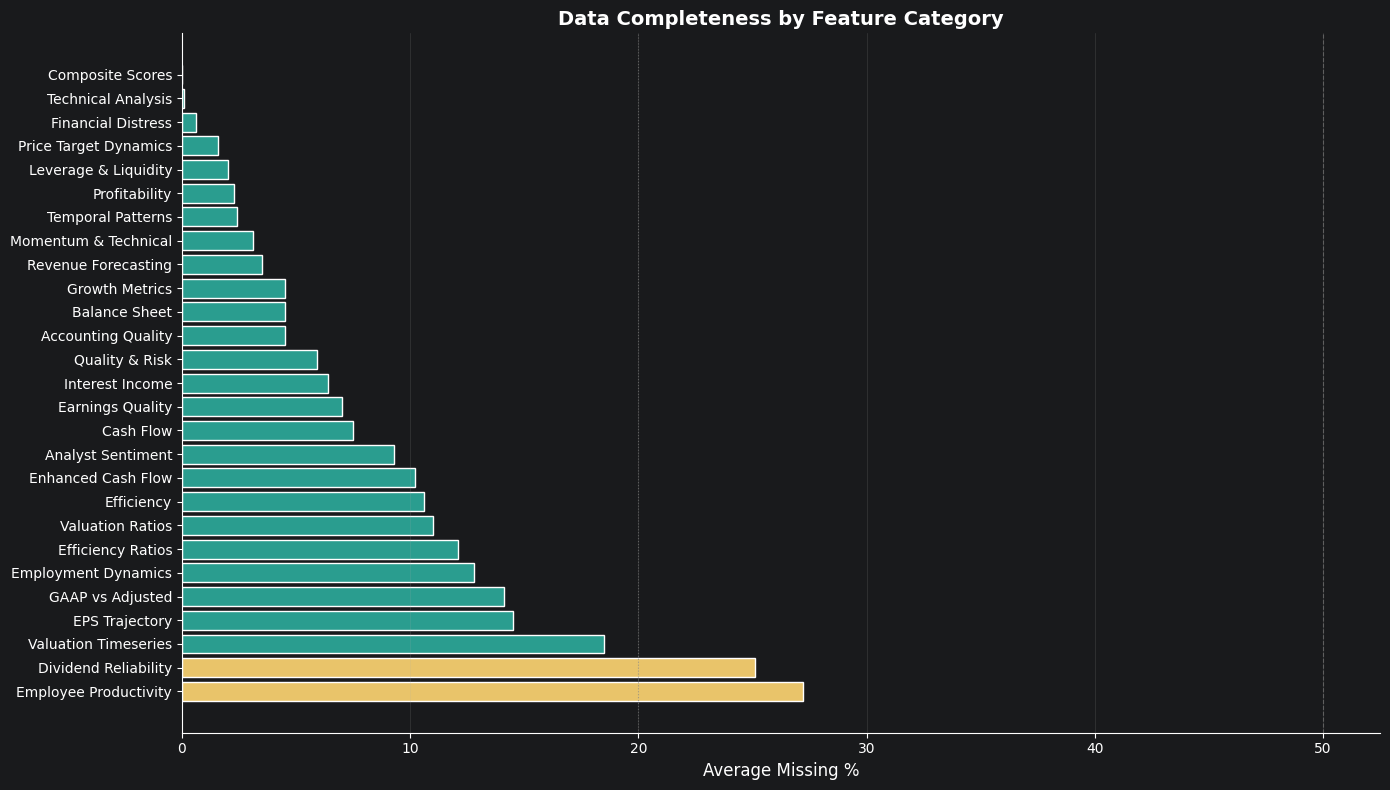

In [8]:
# Visualize missing data by category
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = [
    COLORS["danger"] if v > 50 else COLORS["accent"] if v > 20 else COLORS["secondary"]
    for v in missing_df["avg_missing_pct"]
]
bars = ax.barh(missing_df.index, missing_df["avg_missing_pct"], color=colors_bar, edgecolor="white")
ax.set_xlabel("Average Missing %", fontsize=12)
ax.set_title("Data Completeness by Feature Category", fontsize=14, fontweight="bold")
ax.axvline(20, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Descriptive Statistics by Feature Category

In [9]:
# Summary statistics for each category
for cat_name in FEATURE_CATEGORIES:
    cols = [c for c in FEATURE_CATEGORIES.get(cat_name, []) if c in df.columns]
    if cols:
        print(f"\n{'=' * 60}")
        print(f"  {cat_name} ({len(cols)} features)")
        print(f"{'=' * 60}")
        display(df[cols].describe().round(3))


  Accounting Quality (46 features)


,asset_sale_gain_loss_ltm,asset_sale_frequency,asset_sale_trend,effective_tax_rate_fy,tax_rate_yoy_change,tax_rate_qoq_change,tax_rate_stability,low_tax_flag,tax_rate_trend_4q,effective_tax_rate_ltm,goodwill_3fq,goodwill_change_rate,restructuring_intensity,exceptional_items_frequency,merger_impact_ratio,asset_sale_boost,non_operating_income_share,accounting_quality_score,goodwill_2fq,goodwill_2fy,goodwill_3fy,goodwill_3y_growth,goodwill_4fq,goodwill_4fy,goodwill_accumulation_rate,goodwill_concentration,goodwill_fy,goodwill_ltm,goodwill_qoq_change,goodwill_to_assets_trend,impairment_risk_score,recent_acquisition_flag,goodwill_1fy,goodwill_vs_5y_avg,goodwill_yoy_change,asset_writedown_frequency,has_goodwill_impairment_ltm,quality_issues_count_5y,restructuring_frequency,asset_writedown_ltm,exceptional_items_total_ltm,goodwill_impairment_frequency,goodwill_impairment_ltm,restructuring_ltm,goodwill_1fq,goodwill_fq
count,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,4659.0000,6079.0000,6635.0000,6635.0000,6635.0000,6366.0000,6635.0000,6635.0000,6635.0000,6635.0000,4531.0000,6635.0000,6635.0000,4531.0000,6318.0000,6635.0000,6635.0000,4106.0000,6561.0000,6635.0000,6635.0000,6635.0000,4754.0000,4659.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000
mean,8.2570,4.0980,-2.8520,0.2290,-0.0810,-0.0200,0.4110,0.3640,-0.0280,0.2240,921.7030,20.2050,-0.0020,0.5030,-0.0040,0.2980,0.2680,86.3120,957.8780,1000.1980,962.3990,789.8580,959.5640,932.5930,6.8970,23.0220,1071.1910,933.4380,-3.0290,-0.0530,19.1690,0.0170,1012.6470,1.0620,2021.6850,2.0070,0.0750,3.2790,0.8650,-30.2200,68.1620,0.4070,-14.6320,-19.4820,998.8640,933.8330
std,222.7920,3.8340,177.7670,1.1390,4.7690,1.6170,3.3430,0.4810,1.5460,0.9820,4372.9990,1265.3130,0.0070,0.6670,0.0290,0.4570,2.5690,16.6790,4626.5040,4340.0660,4185.6170,21799.3740,4576.7060,4105.0780,76.8950,222.6510,4783.3290,4480.3520,195.7930,3.6710,32.5680,0.1290,4604.3730,9.0790,126527.3350,2.0430,0.2630,3.0860,1.6380,305.7030,491.3110,0.9340,189.2480,291.2800,4531.8060,4480.3020
min,-11049.1100,0.0000,-13005.0720,0.0000,-307.5180,-51.6740,0.0000,0.0000,-61.2130,0.0000,-1.0700,-3.2210,-0.1950,0.0000,-1.0260,0.0000,0.0000,20.0000,-1.0100,0.0000,0.0000,-100.0000,-0.0400,0.0000,-100.0000,-11438.3840,-1.0100,-1.9100,-100.0000,-53.0280,0.0000,0.0000,0.0000,0.0000,-217.4420,0.0000,0.0000,0.0000,0.0000,-16440.3400,0.0000,0.0000,-6734.0000,-20197.3700,-1.7800,-1.9100
25%,0.0000,0.0000,-0.0280,0.0000,-0.0290,-0.0340,0.0210,0.0000,-0.0610,0.0000,0.0000,-0.0890,0.0000,0.0000,-0.0000,0.0000,0.0150,75.0000,0.0000,0.0000,0.0000,-7.9190,0.0000,0.0000,-2.7130,0.0000,0.0000,0.0000,-1.9310,-0.2750,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-2.4850,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,4.0000,0.0000,0.1630,0.0000,0.0000,0.0910,0.0000,0.0000,0.1800,12.3600,0.0330,0.0000,0.0000,0.0000,0.0000,0.0550,90.0000,12.0300,32.9400,28.3600,2.9910,18.8200,23.3300,0.9870,2.0530,37.9000,13.7500,0.0000,0.0000,2.4570,0.0000,34.9200,0.9990,4.2250,1.0000,0.0000,3.0000,0.0000,0.0000,0.1500,0.0000,0.0000,0.0000,18.3200,14.0100
75%,0.1000,8.0000,0.0000,0.2570,0.0190,0.0150,0.2570,1.0000,0.0230,0.2580,284.7950,0.1260,0.0000,1.0000,0.0000,1.0000,0.1480,100.0000,302.5350,377.6250,347.8800,27.4560,317.4750,322.0150,8.4230,28.3130,418.9750,295.6400,0.8540,0.0380,19.2440,0.0000,382.9950,1.1320,12.9410,4.0000,0.0000,5.0000,1.0000,0.0000,12.9400,0.0000,0.0000,0.0000,337.0900,297.9000
max,9687.0000,10.0000,1925.7500,62.0000,61.8160,76.3640,183.6380,1.0000,75.7830,43.0300,119509.0000,86253.0000,0.0300,3.0000,0.0870,1.0000,178.5450,100.0000,119497.0000,117043.0000,113010.0000,1293710.0000,119329.0000,115796.0000,2247.5970,9991.1070,119509.0000,119661.0000,8000.0000,62.2370,100.0000,1.0000,119220.0000,498.0000,8625300.0000,5.0000,1.0000,15.0000,5.0000,1574.6700,20197.3700,5.0000,498.3400,95.1900,119622.0000


  Analyst Sentiment (23 features)


,ebitda_est_fy1e,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,pe_forward_discount,pe_est_fy1,ebitda_est_ntm,pe_ntm,analyst_bullish_pct,analyst_bearish_pct,analyst_neutral_pct,upside_potential,price_target_spread_pct,price_target_revision_1m,price_target_revision_3m,eps_revision_momentum,analyst_rating_normalized,analyst_coverage_quality,analyst_conviction
count,6635.0000,5495.0000,5421.0000,3187.0000,5979.0000,6304.0000,4479.0000,5139.0000,4907.0000,5700.0000,6635.0000,5742.0000,6550.0000,6632.0000,6632.0000,6635.0000,6635.0000,6577.0000,6532.0000,6635.0000,6635.0000,6635.0000,6632.0000
mean,1552.5230,-0.2750,-0.2390,-0.8630,14.8840,0.1930,0.7650,-0.0760,-0.1680,25.8880,1604.2060,25.6580,67.5310,6.1500,25.2090,25.4610,40.4380,0.0160,0.0590,0.1400,75.9010,0.9900,62.7860
std,8303.8410,3.7900,1.4250,4.1600,21.5980,17.4580,51.3470,1.4500,0.9170,32.9790,8946.7810,33.5550,31.2180,14.1030,26.3870,39.4570,38.6190,0.1130,0.2320,8.5100,21.4780,0.7300,32.6310
min,-3114.4000,-262.6200,-62.8300,-117.1500,0.0000,-208.5260,-11.0890,-1.0000,-1.0000,0.7000,-3332.0900,0.0000,0.0000,0.0000,0.0000,-95.5600,0.0000,-1.0000,-1.0000,-0.8950,-25.0000,0.0930,0.0000
25%,81.0600,-0.1400,-0.1500,-0.9000,6.5000,0.0300,-0.0140,-0.4910,-0.4310,11.9000,82.9350,11.8000,50.0000,0.0000,0.0000,5.0640,15.8730,-0.0120,-0.0370,-0.0260,66.0000,0.4070,38.4620
50%,316.7100,-0.0100,-0.0100,-0.0500,9.6000,0.1930,0.0000,-0.2240,-0.2240,17.0000,325.5600,16.8000,75.0000,0.0000,20.0000,18.8290,35.1220,0.0000,0.0140,0.0000,80.0000,0.8250,66.6670
75%,1012.1950,0.0000,0.0000,0.0300,15.3000,0.4500,0.0220,0.0380,-0.0740,27.4000,1028.3350,26.9000,100.0000,6.6670,41.6670,36.4230,55.5630,0.0230,0.1080,0.0210,91.2500,1.4330,100.0000
max,267825.3800,35.4900,35.2300,42.5100,439.2000,1208.0000,3436.1160,60.0660,27.3570,489.4000,298107.4800,489.4000,100.0000,100.0000,100.0000,563.2650,893.0000,2.1250,3.4440,689.8510,100.0000,4.5380,100.0000



  Balance Sheet (51 features)


...

,fiscal_quarter,fiscal_month,fiscal_year,days_to_earnings,earnings_report_recency,reporting_lag,fiscal_year_progress,days_since_last_report,earnings_season_flag,fiscal_quarter_progress,is_fy_end_month,is_quarter_end_month,post_earnings_window,pre_earnings_window,reporting_freshness_score,days_to_fy_end
count,6293.0000,6293.0000,6293.0000,6635.0000,6375.0000,6375.0000,6293.0000,6375.0000,6635.0000,6293.0000,6635.0000,6635.0000,6635.0000,6635.0000,6635.0000,6526.0000
mean,3.0720,9.1430,2025.9960,37.2040,110.9700,76.3710,0.7620,110.9700,1.0000,0.9760,0.0050,0.0000,0.0000,0.4660,17.0210,-172.4010
std,1.2410,3.7870,0.3000,42.3480,85.9070,89.0930,0.3160,85.9070,0.0000,0.0880,0.0730,0.0000,0.0000,0.4990,30.7800,122.6640
min,1.0000,2.0000,2013.0000,-1.0000,27.0000,-15.0000,0.1670,27.0000,1.0000,0.3330,0.0000,0.0000,0.0000,0.0000,0.0000,-4869.0000
25%,2.0000,5.0000,2026.0000,6.0000,121.0000,37.0000,0.4170,121.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-121.0000
50%,4.0000,12.0000,2026.0000,13.0000,121.0000,59.0000,1.0000,121.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-121.0000
75%,4.0000,12.0000,2026.0000,77.0000,121.0000,97.0000,1.0000,121.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,-121.0000
max,4.0000,12.0000,2027.0000,307.0000,4596.0000,4562.0000,1.0000,4596.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,100.0000,-31.0000



  Valuation Ratios (16 features)


,p_e_ratio,p_b_ratio,ev_ebitda_ratio,ev_sales_ratio,peg_ratio,valuation_dividend_yield,tangible_book_per_share,tangible_equity_ratio,price_to_tangible_book,intangibles_to_equity,goodwill_to_equity,tangible_asset_quality,tangible_book_value_fy,tangible_book_value_ltm,tbv_vs_calculated,tbv_yoy_growth
count,5104.0000,6068.0000,5646.0000,6170.0000,4249.0000,3997.0000,6635.0000,6079.0000,5128.0000,6318.0000,6318.0000,6635.0000,6635.0000,6635.0000,6319.0000,6579.0000
mean,39.8410,5.0750,19.0630,5.9420,-0.0130,0.0320,0.0000,29.1590,8.8040,41.5320,23.0220,85.8150,2247.5470,2217.5140,0.1950,0.3430
std,54.1570,9.9720,30.6160,20.4650,18.8460,0.0530,0.0000,51.2780,21.9840,1561.1470,222.6510,22.1200,12260.8090,12477.1350,53.2870,198.0330
min,0.0000,0.1000,0.0000,0.0000,-915.2300,0.0000,-0.0000,-2800.0000,0.2000,-6234.3430,-11438.3840,0.0000,-81994.8300,-81994.8300,-3674.5000,-4954.0980
25%,14.8000,1.5000,7.3000,1.1000,-1.5150,0.0100,0.0000,9.1340,1.9000,0.0000,0.0000,79.9620,53.5600,29.7550,0.7590,0.0000
50%,22.6000,2.6000,10.9000,2.2000,0.3270,0.0230,0.0000,31.6560,3.6000,0.0000,2.0530,97.4650,492.4300,445.9500,0.9570,0.0000
75%,40.6000,5.1000,18.5000,4.6000,1.6420,0.0410,0.0000,53.7050,7.9000,13.8670,28.3130,100.0000,1822.4650,1732.8550,1.0000,0.0180
max,485.0000,235.7000,497.1000,474.8000,337.4160,1.8760,0.0210,99.9320,472.3000,120671.4290,9991.1070,100.0000,378595.0000,418465.0000,1482.1670,14000.0000



  Valuation Timeseries (22 features)


,ev_sales_trend_1y,ev_ebitda_momentum,p_e_momentum_yoy,p_e_momentum_qoq,ev_sales_vs_3y_avg,ev_ebitda_vs_3y_avg,p_e_vs_3y_avg,ev_sales_forward_discount,ev_ebitda_forward_discount,p_e_forward_discount,p_b_vs_5y_avg,ev_sales_qoq_1q,p_b_momentum_yoy,forward_pe_premium,ev_ebitda_qoq_trend,ev_sales_qoq_2q,ev_sales_qoq_4q,p_e_percentile_proxy,p_e_vs_5y_avg,valuation_compression,valuation_mean_reversion,ev_sales_qoq_3q
count,6117.0000,5612.0000,5072.0000,5072.0000,5735.0000,5215.0000,4694.0000,6026.0000,5452.0000,4894.0000,5173.0000,6130.0000,6028.0000,4894.0000,5617.0000,6426.0000,6391.0000,4694.0000,4372.0000,4453.0000,4447.0000,6393.0000
mean,0.1250,0.0910,0.1620,0.2310,0.1600,0.1110,0.2390,-0.0720,-0.1250,-0.1720,1.1600,0.1020,0.1230,-17.1720,0.3120,0.3270,0.1450,0.4770,0.2630,0.1660,0.1600,0.4730
std,1.0310,0.6340,1.0260,1.3410,0.6580,0.6580,0.9540,0.9930,0.6400,0.6790,0.9400,0.7220,0.7190,67.9390,16.9700,18.8350,5.0430,1.9070,1.1820,0.6580,0.5560,28.2640
min,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-0.9820,-0.9860,0.0380,-1.0000,-0.9380,-98.5780,-1.0000,-1.0000,-1.0000,-2.0000,-1.0000,-0.8770,-0.8330,-0.9980
25%,-0.0620,-0.0730,-0.0720,-0.0980,-0.1580,-0.2000,-0.2310,-0.1670,-0.2820,-0.4130,0.7000,-0.0910,-0.0790,-41.3370,-0.1040,-0.0880,-0.1430,-0.4630,-0.3130,-0.1990,-0.1630,0.0000
50%,0.0000,0.0170,0.0270,0.0300,0.0260,0.0000,0.0390,-0.0830,-0.1370,-0.2060,1.0000,0.0000,0.0000,-20.6160,0.0110,0.0000,0.0000,0.0770,0.0000,0.0210,0.0400,0.0000
75%,0.1430,0.1220,0.1490,0.2130,0.3160,0.2550,0.4040,0.0000,-0.0340,-0.0590,1.3570,0.1540,0.1670,-5.8730,0.1480,0.1120,0.1430,0.8090,0.4290,0.3350,0.3210,0.1000
max,56.3110,25.1630,27.4710,35.3640,22.5000,21.3510,12.7720,70.6670,31.6150,17.1010,34.3910,24.4620,21.7140,1710.1120,1271.0000,1507.0000,288.4620,25.5430,17.6760,10.4660,7.1440,2249.0000


## 4. Valuation Analysis

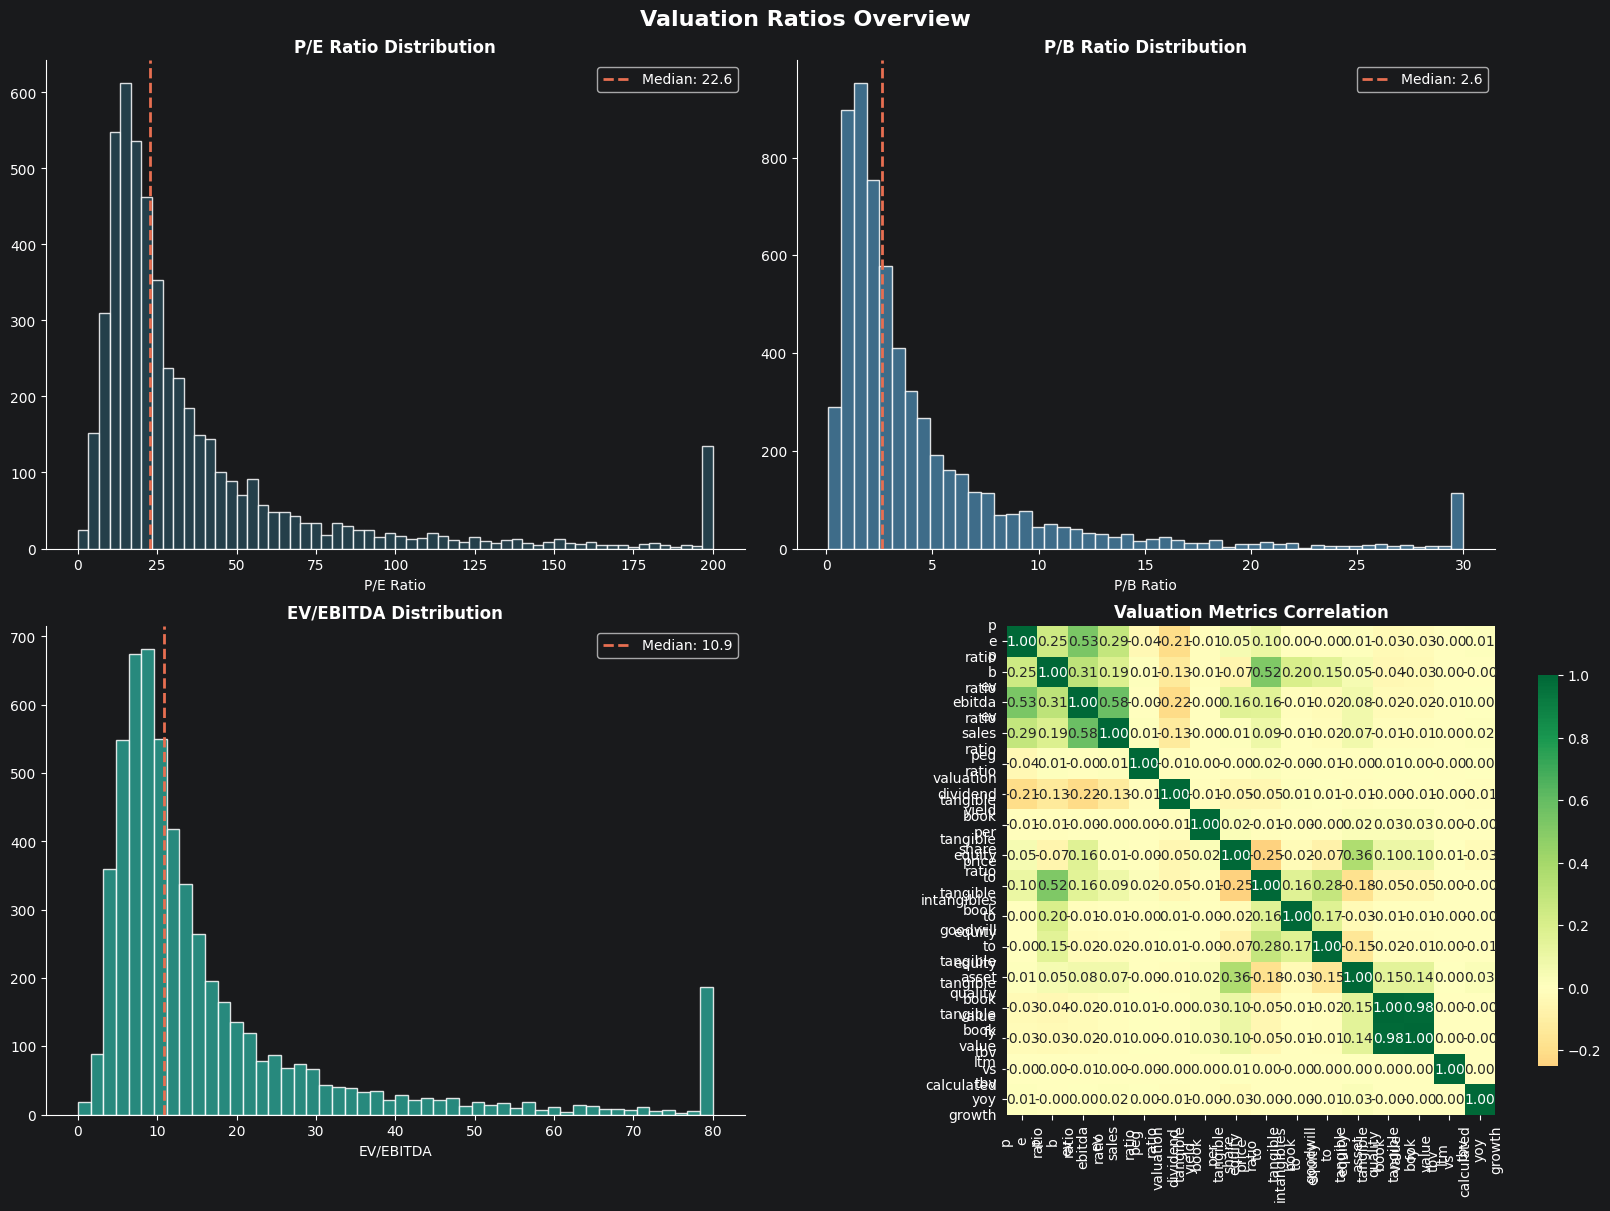

In [10]:
val_cols = [c for c in FEATURE_CATEGORIES.get("Valuation Ratios", []) if c in df.columns]
if len(val_cols) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle("Valuation Ratios Overview", fontsize=16, fontweight="bold")

    # P/E Distribution
    ax = axes[0, 0]
    pe_col = next((c for c in ["p_e_ratio"] if c in df.columns), None)
    if pe_col:
        pe_data = df[pe_col].dropna().clip(-50, 200)
        ax.hist(pe_data, bins=60, color=COLORS["primary"], alpha=0.85, edgecolor="white")
        ax.axvline(pe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pe_data.median():.1f}")
        ax.set_title("P/E Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/E Ratio")
        ax.legend()

    # P/B Distribution
    ax = axes[0, 1]
    pb_col = next((c for c in ["p_b_ratio"] if c in df.columns), None)
    if pb_col:
        pb_data = df[pb_col].dropna().clip(0, 30)
        ax.hist(pb_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(pb_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {pb_data.median():.1f}")
        ax.set_title("P/B Ratio Distribution", fontweight="bold")
        ax.set_xlabel("P/B Ratio")
        ax.legend()

    # EV/EBITDA Distribution
    ax = axes[1, 0]
    ev_col = next((c for c in ["ev_ebitda_ratio"] if c in df.columns), None)
    if ev_col:
        ev_data = df[ev_col].dropna().clip(-10, 80)
        ax.hist(ev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(ev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {ev_data.median():.1f}")
        ax.set_title("EV/EBITDA Distribution", fontweight="bold")
        ax.set_xlabel("EV/EBITDA")
        ax.legend()

    # Valuation correlation heatmap
    ax = axes[1, 1]
    val_data = df[val_cols].dropna(thresh=len(val_cols) // 2)
    if len(val_data) > 10:
        corr = val_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                    ax=ax, cbar_kws={"shrink": 0.8}, square=True,
                    xticklabels=[c.replace("_", "\n") for c in corr.columns],
                    yticklabels=[c.replace("_", "\n") for c in corr.columns])
        ax.set_title("Valuation Metrics Correlation", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 5. Profitability & Margins Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_48324\504397710.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)


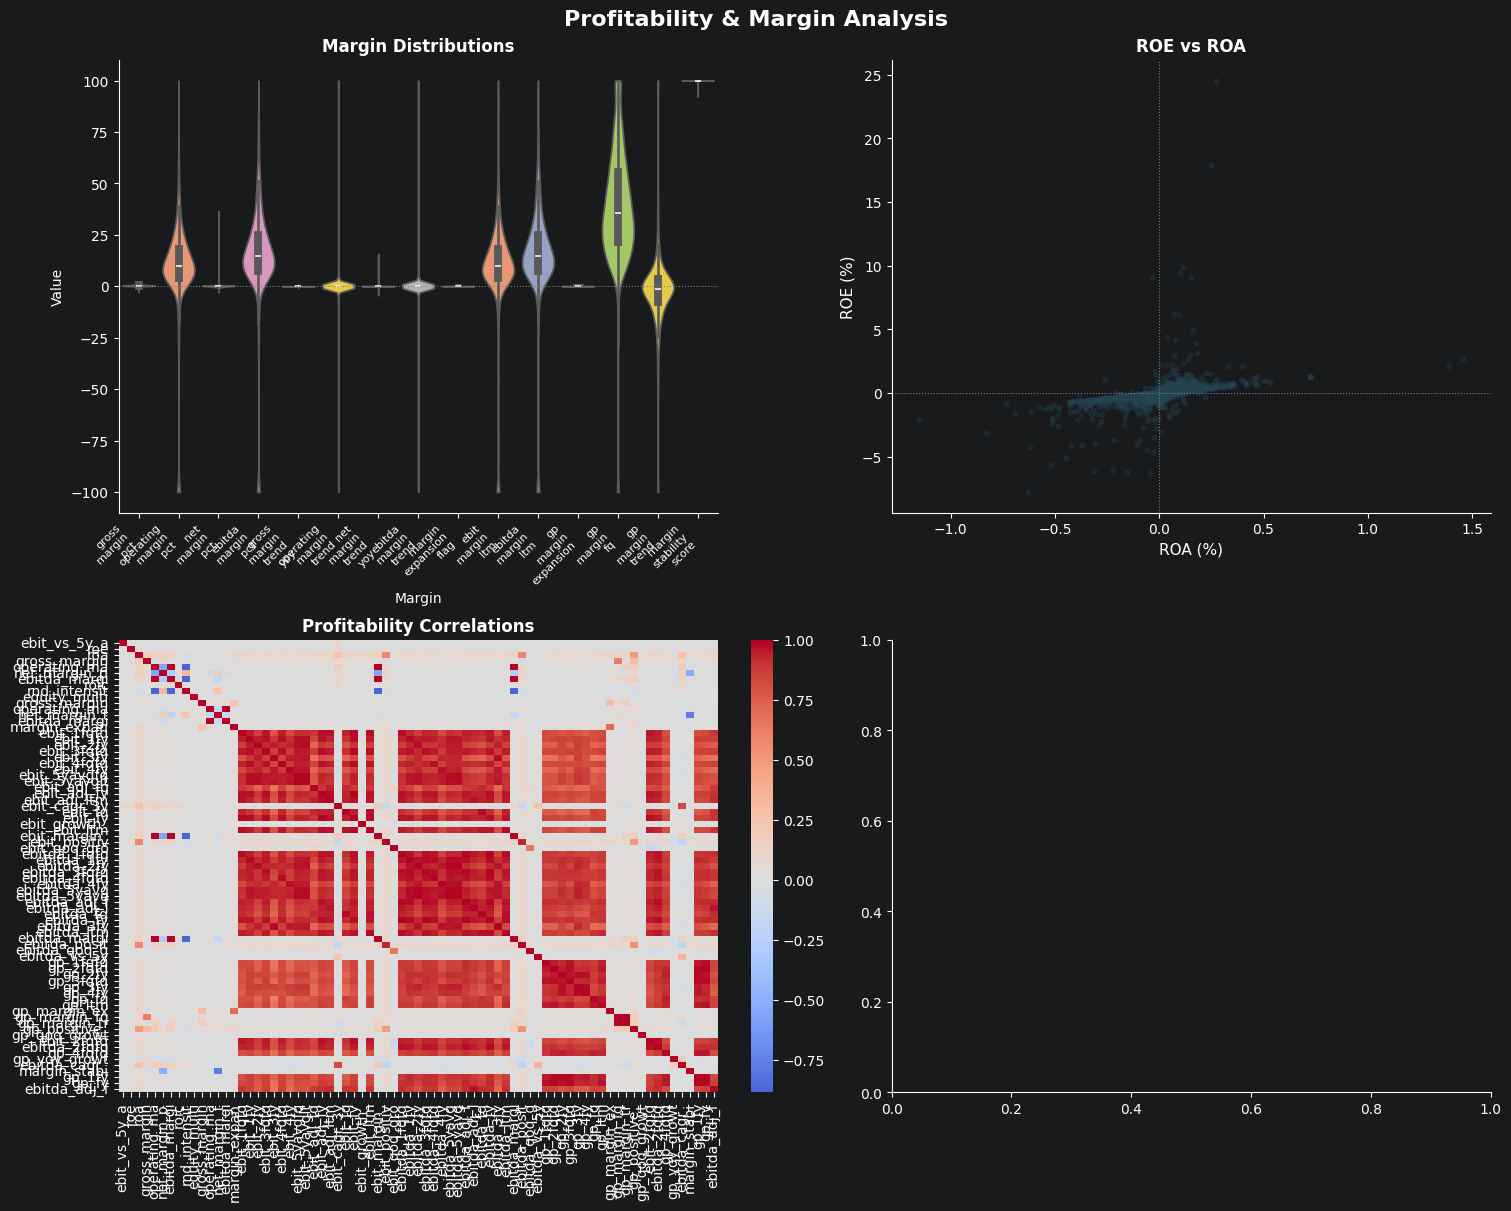

In [11]:
prof_cols = [c for c in FEATURE_CATEGORIES.get("Profitability", []) if c in df.columns]
margin_cols = [c for c in prof_cols if "margin" in c.lower()]
if margin_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
    fig.suptitle("Profitability & Margin Analysis", fontsize=16, fontweight="bold")

    # Margin distributions (violin)
    ax = axes[0, 0]
    margin_data = df[margin_cols].melt(var_name="Margin", value_name="Value")
    margin_data["Value"] = margin_data["Value"].clip(-100, 100)
    sns.violinplot(data=margin_data, x="Margin", y="Value", ax=ax, inner="box",
                   palette="Set2", cut=0)
    ax.set_xticklabels([c.replace("_", "\n") for c in margin_cols], rotation=45, ha="right", fontsize=8)
    ax.set_title("Margin Distributions", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)

    # ROE vs ROA scatter
    ax = axes[0, 1]
    roe_col = next((c for c in ["roe"] if c in df.columns), None)
    roa_col = next((c for c in ["roa"] if c in df.columns), None)
    if roe_col and roa_col:
        valid = df[[roe_col, roa_col]].dropna()
        valid = valid[(valid[roe_col].between(-100, 200)) & (valid[roa_col].between(-50, 50))]
        ax.scatter(valid[roa_col], valid[roe_col], alpha=0.3, s=10, c=COLORS["primary"])
        ax.set_xlabel("ROA (%)", fontsize=11)
        ax.set_ylabel("ROE (%)", fontsize=11)
        ax.set_title("ROE vs ROA", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    # Profitability correlation
    ax = axes[1, 0]
    if len(prof_cols) >= 3:
        prof_data = df[prof_cols].dropna(thresh=len(prof_cols) // 2)
        if len(prof_data) > 10:
            corr = prof_data.corr()
            sns.heatmap(corr, annot=False, fmt=".1f", cmap="coolwarm", center=0, ax=ax,
                        xticklabels=[c[:12] for c in corr.columns],
                        yticklabels=[c[:12] for c in corr.columns], square=False)
            ax.set_title("Profitability Correlations", fontweight="bold")

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 6. Technical Analysis Analysis

C:\Users\markm\AppData\Local\Temp\ipykernel_48324\828036699.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],


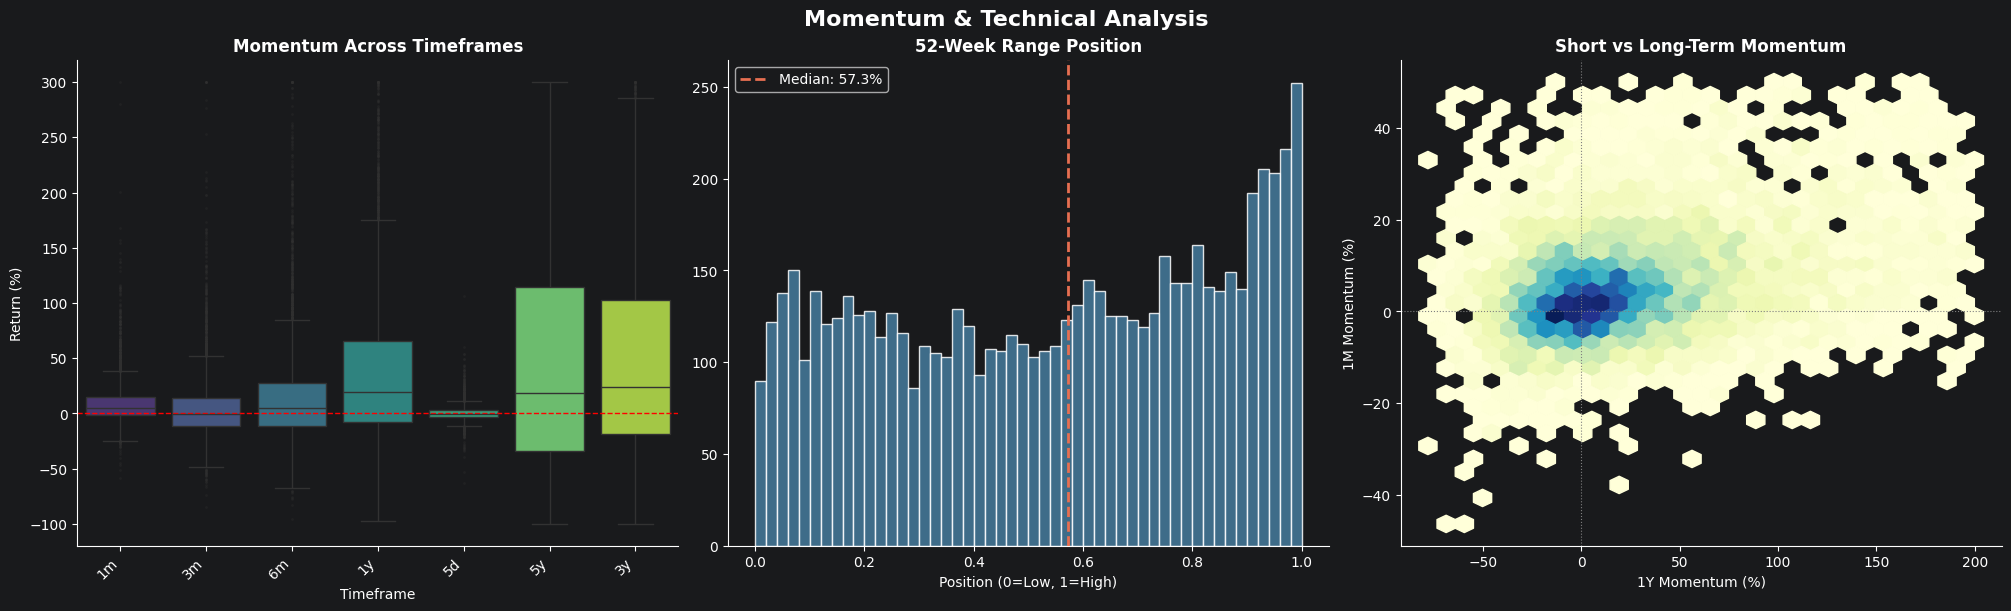

In [12]:
mom_cols = [c for c in FEATURE_CATEGORIES.get("Technical Analysis", []) if c in df.columns]
price_mom_cols = [c for c in mom_cols if c.startswith("price_momentum")]
if price_mom_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Technical Analysis Analysis", fontsize=16, fontweight="bold")

    # Momentum ribbon (box plots across timeframes)
    ax = axes[0]
    mom_data = df[price_mom_cols].melt(var_name="Timeframe", value_name="Return")
    mom_data["Return"] = mom_data["Return"].clip(-100, 300)
    sns.boxplot(data=mom_data, x="Timeframe", y="Return", ax=ax, palette="viridis",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("price_momentum_", "") for c in price_mom_cols],
                       rotation=45, ha="right")
    ax.axhline(0, color="red", linestyle="--", lw=1)
    ax.set_title("Momentum Across Timeframes", fontweight="bold")
    ax.set_ylabel("Return (%)")

    # 52-week range position histogram
    ax = axes[1]
    range_col = next((c for c in ["range_52w_position"] if c in df.columns), None)
    if range_col:
        range_data = df[range_col].dropna()
        ax.hist(range_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
        ax.axvline(range_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
                   label=f"Median: {range_data.median():.1%}")
        ax.set_title("52-Week Range Position", fontweight="bold")
        ax.set_xlabel("Position (0=Low, 1=High)")
        ax.legend()

    # Short vs long-term momentum scatter
    ax = axes[2]
    short_col = next((c for c in ["price_momentum_1m"] if c in df.columns), None)
    long_col = next((c for c in ["price_momentum_1y"] if c in df.columns), None)
    if short_col and long_col:
        valid = df[[short_col, long_col]].dropna()
        valid = valid[valid[short_col].between(-50, 50) & valid[long_col].between(-80, 200)]
        ax.hexbin(valid[long_col], valid[short_col], gridsize=30, cmap="YlGnBu", mincnt=1)
        ax.set_xlabel("1Y Momentum (%)")
        ax.set_ylabel("1M Momentum (%)")
        ax.set_title("Short vs Long-Term Momentum", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 7. Earnings Quality & EPS Trajectory

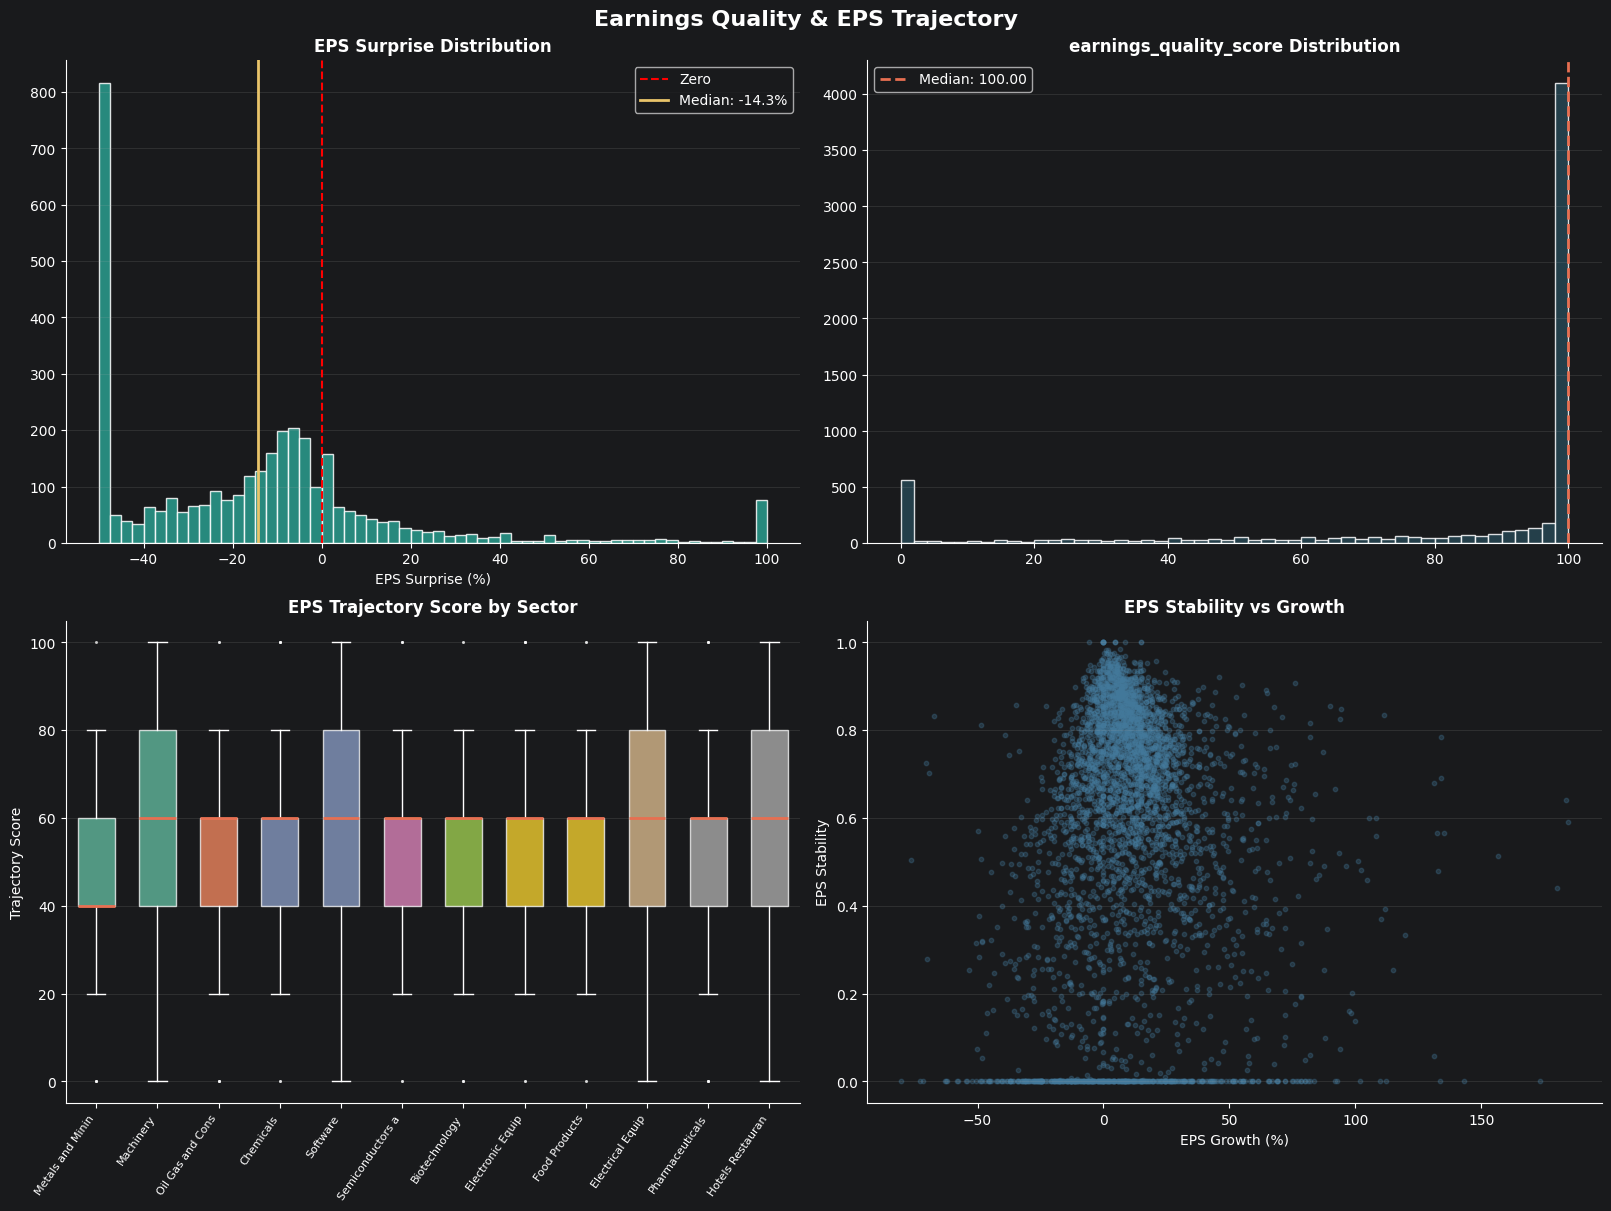

In [13]:
eq_cols = [c for c in FEATURE_CATEGORIES.get("Earnings Quality", []) if c in df.columns]
eps_cols = [c for c in FEATURE_CATEGORIES.get("EPS Trajectory", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Earnings Quality & EPS Trajectory", fontsize=16, fontweight="bold")

# EPS surprise distribution
ax = axes[0, 0]
surprise_col = next((c for c in ["eps_surprise_pct"] if c in df.columns), None)
if surprise_col:
    surprise_data = df[surprise_col].dropna().clip(-50, 100)
    ax.hist(surprise_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero")
    ax.axvline(surprise_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {surprise_data.median():.1f}%")
    ax.set_title("EPS Surprise Distribution", fontweight="bold")
    ax.set_xlabel("EPS Surprise (%)")
    ax.legend()

# Earnings quality score distribution
ax = axes[0, 1]
eq_score = next((c for c in ["earnings_quality_score", "earnings_quality_composite"] if c in df.columns), None)
if eq_score:
    score_data = df[eq_score].dropna()
    ax.hist(score_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(score_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {score_data.median():.2f}")
    ax.set_title(f"{eq_score} Distribution", fontweight="bold")
    ax.legend()

# EPS trajectory score by sector
ax = axes[1, 0]
traj_col = next((c for c in ["eps_trajectory_score"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if traj_col and sector_col:
    sectors = df[sector_col].value_counts().head(12).index
    sector_data = [df.loc[df[sector_col] == s, traj_col].dropna().values for s in sectors]
    bp = ax.boxplot(sector_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("EPS Trajectory Score by Sector", fontweight="bold")
    ax.set_ylabel("Trajectory Score")

# EPS stability vs growth scatter
ax = axes[1, 1]
stab_col = next((c for c in ["eps_stability"] if c in df.columns), None)
growth_col = next((c for c in ["eps_cagr_5y", "eps_yoy_growth"] if c in df.columns), None)
if stab_col and growth_col:
    valid = df[[stab_col, growth_col]].dropna()
    valid = valid[valid[growth_col].between(-100, 200)]
    ax.scatter(valid[growth_col], valid[stab_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("EPS Growth (%)")
    ax.set_ylabel("EPS Stability")
    ax.set_title("EPS Stability vs Growth", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 8. Growth Metrics Analysis

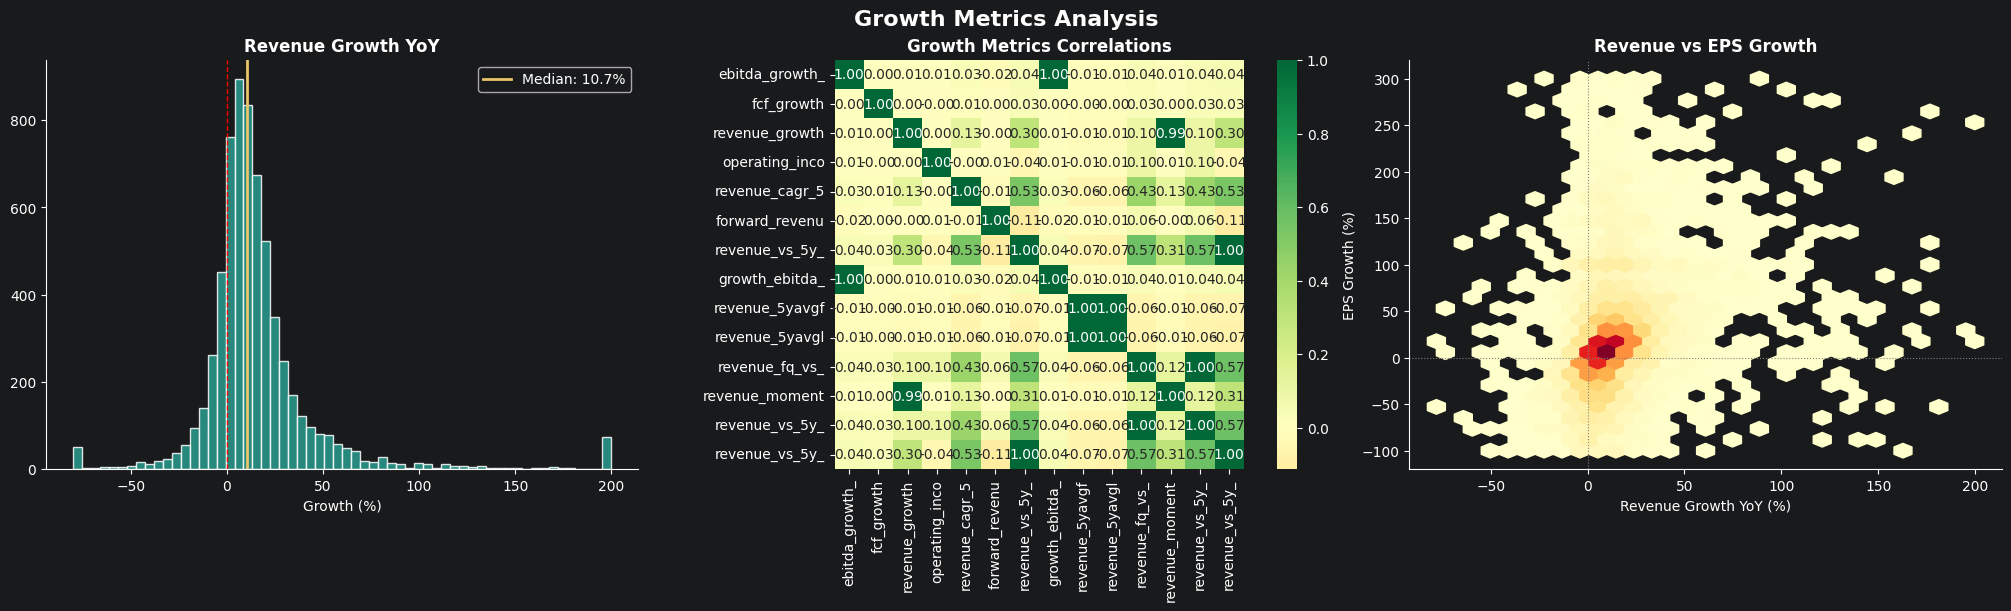

In [14]:
growth_cols = [c for c in FEATURE_CATEGORIES.get("Growth Metrics", []) if c in df.columns]
if growth_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    fig.suptitle("Growth Metrics Analysis", fontsize=16, fontweight="bold")

    # Revenue growth distribution
    ax = axes[0]
    rev_col = next((c for c in ["revenue_growth_yoy"] if c in df.columns), None)
    if rev_col:
        rev_data = df[rev_col].dropna().clip(-80, 200)
        ax.hist(rev_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
        ax.axvline(0, color="red", linestyle="--", lw=1)
        ax.axvline(rev_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
                   label=f"Median: {rev_data.median():.1f}%")
        ax.set_title("Revenue Growth YoY", fontweight="bold")
        ax.set_xlabel("Growth (%)")
        ax.legend()

    # Growth correlation heatmap
    ax = axes[1]
    g_data = df[growth_cols].dropna(thresh=len(growth_cols) // 2)
    if len(g_data) > 10:
        corr = g_data.corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Growth Metrics Correlations", fontweight="bold")

    # Revenue vs EPS growth scatter
    ax = axes[2]
    eps_g = next((c for c in ["eps_yoy_growth", "eps_cagr_5y"] if c in df.columns), None)
    if rev_col and eps_g:
        valid = df[[rev_col, eps_g]].dropna()
        valid = valid[valid[rev_col].between(-80, 200) & valid[eps_g].between(-100, 300)]
        ax.hexbin(valid[rev_col], valid[eps_g], gridsize=30, cmap="YlOrRd", mincnt=1)
        ax.set_xlabel("Revenue Growth YoY (%)")
        ax.set_ylabel("EPS Growth (%)")
        ax.set_title("Revenue vs EPS Growth", fontweight="bold")
        ax.axhline(0, color="grey", linestyle=":", lw=0.8)
        ax.axvline(0, color="grey", linestyle=":", lw=0.8)

    for a in axes.flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
    plt.show()

## 9. Quality & Risk Assessment

C:\Users\markm\AppData\Local\Temp\ipykernel_48324\2282882155.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


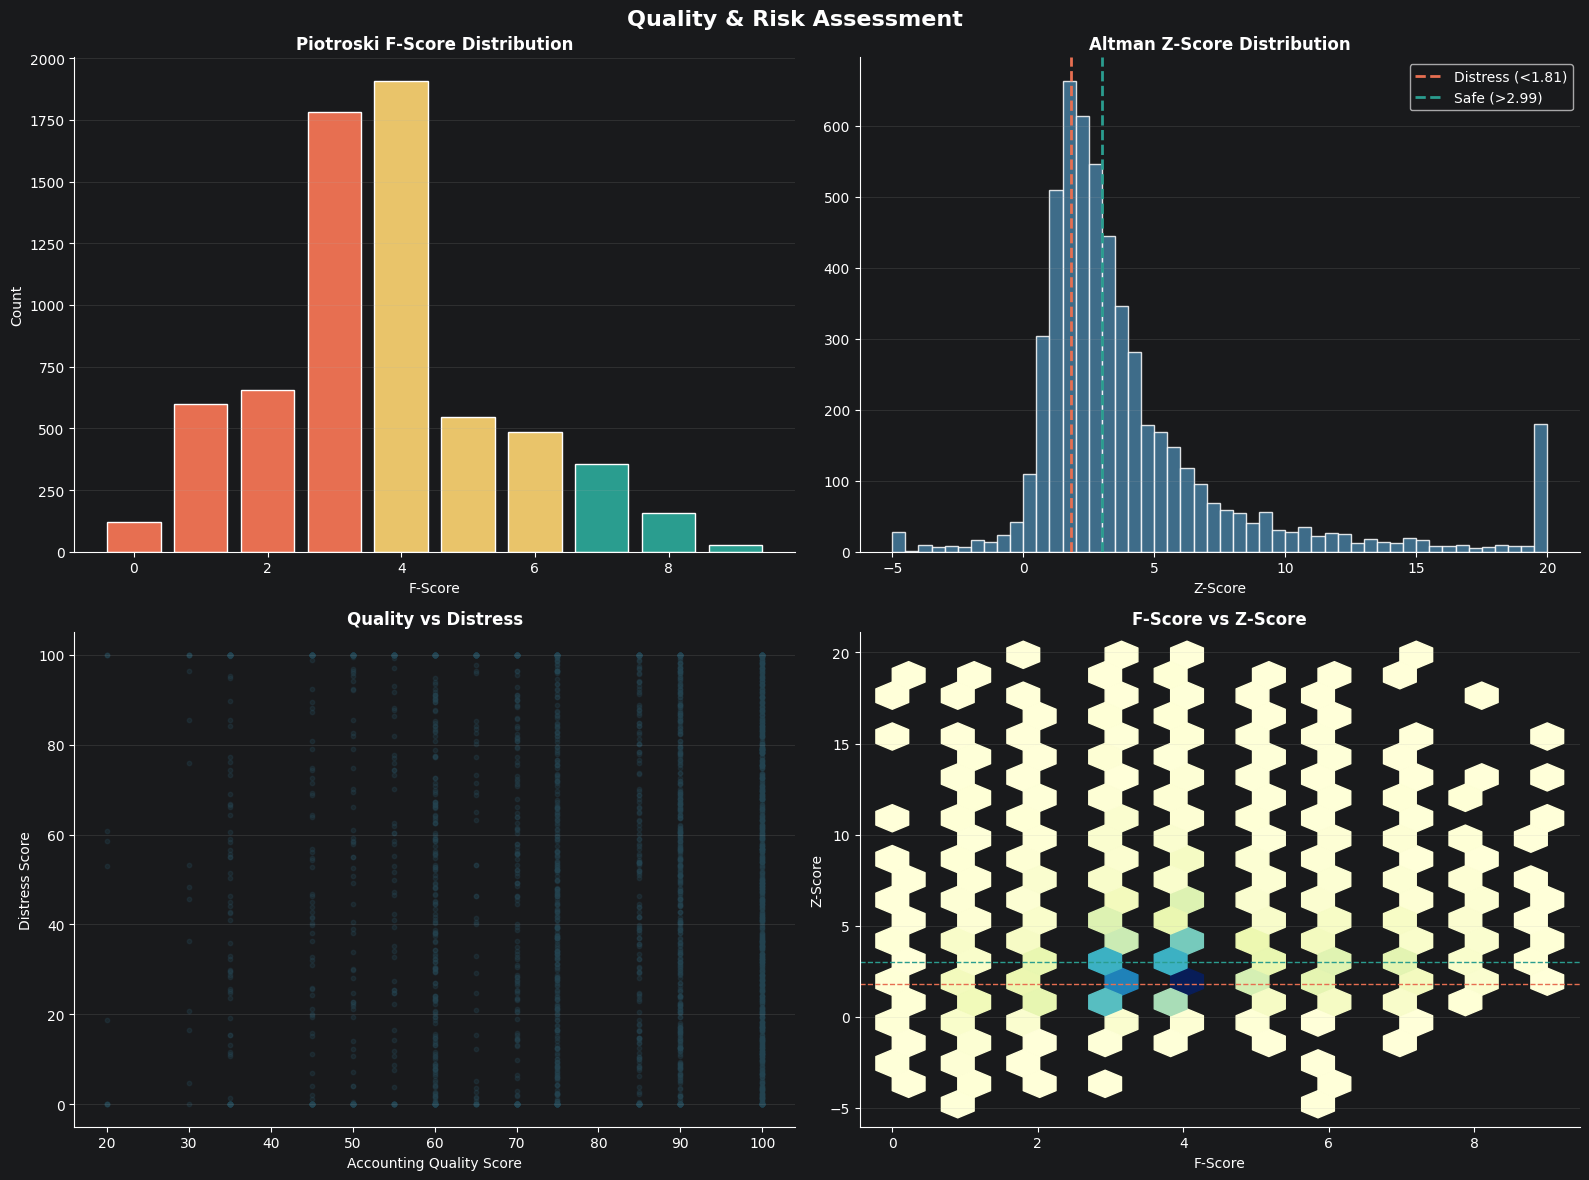

In [15]:
qr_cols = [c for c in FEATURE_CATEGORIES.get("Quality & Risk", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Quality & Risk Assessment", fontsize=16, fontweight="bold")

# Piotroski F-Score distribution
ax = axes[0, 0]
fscore_col = next((c for c in ["piotroski_f_score"] if c in df.columns), None)
if fscore_col:
    fscore_data = df[fscore_col].dropna()
    counts = fscore_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 3 else COLORS["accent"] if v <= 6
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("Piotroski F-Score Distribution", fontweight="bold")
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Count")

# Altman Z-Score distribution
ax = axes[0, 1]
zscore_col = next((c for c in ["altman_z_score", "altman_z_score_fy"] if c in df.columns), None)
if zscore_col:
    zscore_data = df[zscore_col].dropna().clip(-5, 20)
    ax.hist(zscore_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.81, color=COLORS["danger"], linestyle="--", lw=2, label="Distress (<1.81)")
    ax.axvline(2.99, color=COLORS["secondary"], linestyle="--", lw=2, label="Safe (>2.99)")
    ax.set_title("Altman Z-Score Distribution", fontweight="bold")
    ax.set_xlabel("Z-Score")
    ax.legend()

# Quality score vs Risk scatter
ax = axes[1, 0]
aq_col = next((c for c in ["accounting_quality_score"] if c in df.columns), None)
distress_col = next((c for c in ["combined_distress_score"] if c in df.columns), None)
if aq_col and distress_col:
    valid = df[[aq_col, distress_col]].dropna()
    ax.scatter(valid[aq_col], valid[distress_col], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Accounting Quality Score")
    ax.set_ylabel("Distress Score")
    ax.set_title("Quality vs Distress", fontweight="bold")

# F-Score vs Z-Score joint distribution
ax = axes[1, 1]
if fscore_col and zscore_col:
    valid = df[[fscore_col, zscore_col]].dropna()
    valid = valid[valid[zscore_col].between(-5, 20)]
    ax.hexbin(valid[fscore_col], valid[zscore_col], gridsize=20, cmap="YlGnBu", mincnt=1)
    ax.set_xlabel("F-Score")
    ax.set_ylabel("Z-Score")
    ax.set_title("F-Score vs Z-Score", fontweight="bold")
    ax.axhline(1.81, color=COLORS["danger"], linestyle="--", lw=1)
    ax.axhline(2.99, color=COLORS["secondary"], linestyle="--", lw=1)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Leverage & Liquidity Analysis

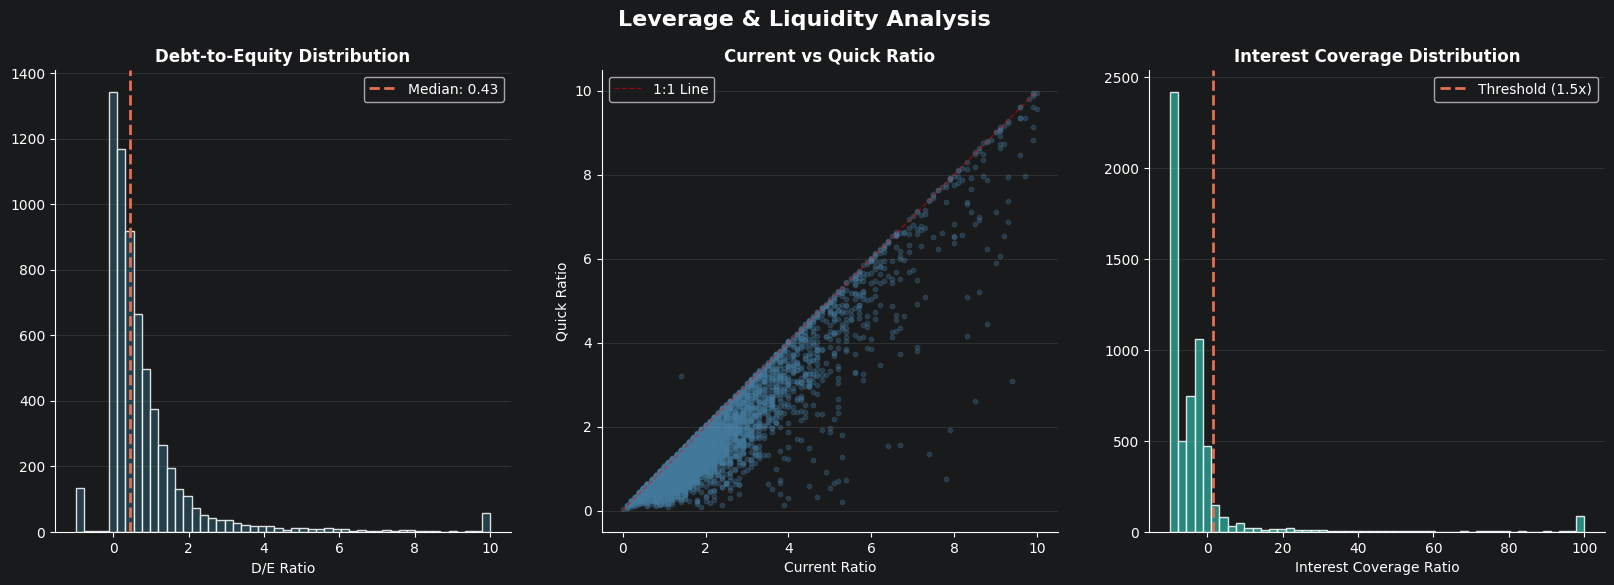

In [16]:
lev_cols = [c for c in FEATURE_CATEGORIES.get("Leverage & Liquidity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Leverage & Liquidity Analysis", fontsize=16, fontweight="bold")

# Debt-to-Equity distribution
ax = axes[0]
dte_col = next((c for c in ["debt_to_equity"] if c in df.columns), None)
if dte_col:
    dte_data = df[dte_col].dropna().clip(-1, 10)
    ax.hist(dte_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(dte_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dte_data.median():.2f}")
    ax.set_title("Debt-to-Equity Distribution", fontweight="bold")
    ax.set_xlabel("D/E Ratio")
    ax.legend()

# Current Ratio vs Quick Ratio
ax = axes[1]
cr_col = next((c for c in ["current_ratio"] if c in df.columns), None)
qr_col = next((c for c in ["quick_ratio"] if c in df.columns), None)
if cr_col and qr_col:
    valid = df[[cr_col, qr_col]].dropna()
    valid = valid[(valid[cr_col].between(0, 10)) & (valid[qr_col].between(0, 10))]
    ax.scatter(valid[cr_col], valid[qr_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.plot([0, 10], [0, 10], "r--", lw=1, alpha=0.5, label="1:1 Line")
    ax.set_xlabel("Current Ratio")
    ax.set_ylabel("Quick Ratio")
    ax.set_title("Current vs Quick Ratio", fontweight="bold")
    ax.legend()

# Interest coverage distribution
ax = axes[2]
ic_col = next((c for c in ["interest_coverage"] if c in df.columns), None)
if ic_col:
    ic_data = df[ic_col].dropna().clip(-10, 100)
    ax.hist(ic_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(1.5, color=COLORS["danger"], linestyle="--", lw=2, label="Threshold (1.5x)")
    ax.set_title("Interest Coverage Distribution", fontweight="bold")
    ax.set_xlabel("Interest Coverage Ratio")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 11. Analyst Sentiment & Price Targets

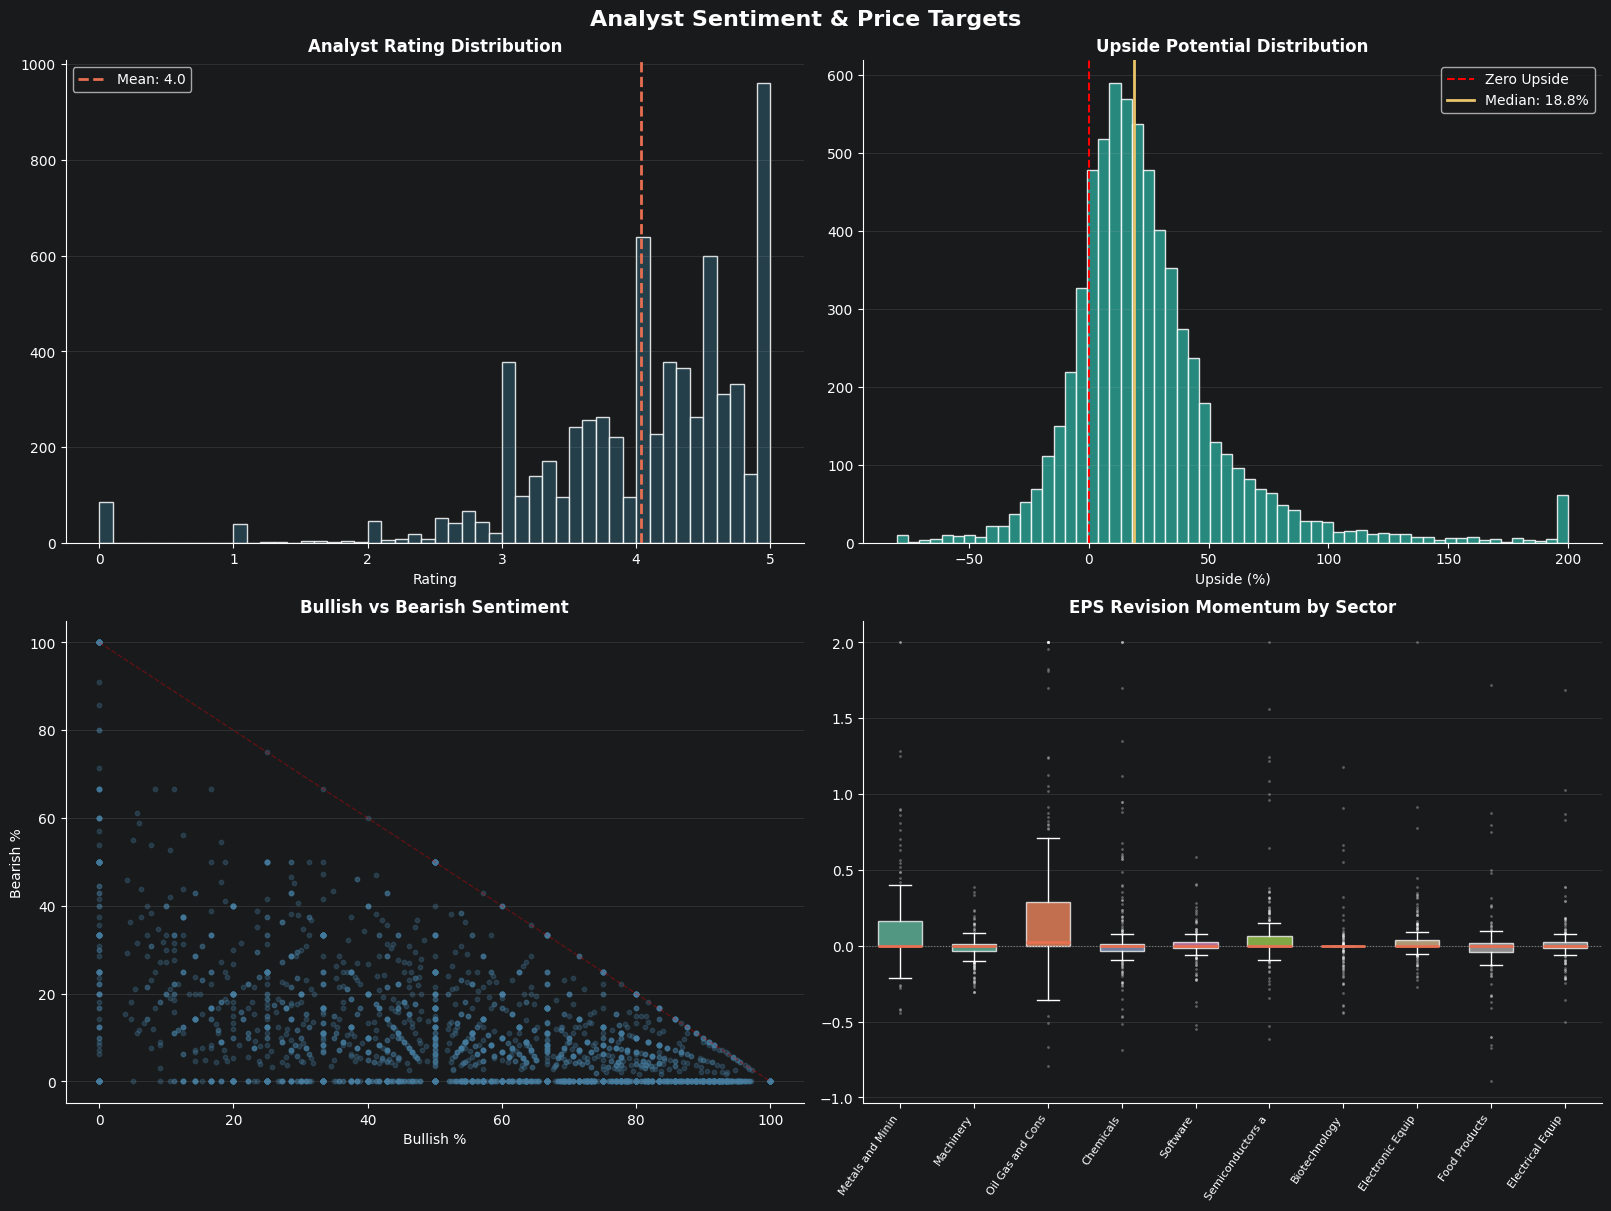

In [17]:
sent_cols = [c for c in FEATURE_CATEGORIES.get("Analyst Sentiment", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Analyst Sentiment & Price Targets", fontsize=16, fontweight="bold")

# Analyst rating distribution
ax = axes[0, 0]
rating_col = next((c for c in ["analyst_rating"] if c in df.columns), None)
if rating_col:
    rating_data = df[rating_col].dropna()
    ax.hist(rating_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(rating_data.mean(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Mean: {rating_data.mean():.1f}")
    ax.set_title("Analyst Rating Distribution", fontweight="bold")
    ax.set_xlabel("Rating")
    ax.legend()

# Upside potential distribution
ax = axes[0, 1]
upside_col = next((c for c in ["upside_potential"] if c in df.columns), None)
if upside_col:
    upside_data = df[upside_col].dropna().clip(-80, 200)
    ax.hist(upside_data, bins=60, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Upside")
    ax.axvline(upside_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {upside_data.median():.1f}%")
    ax.set_title("Upside Potential Distribution", fontweight="bold")
    ax.set_xlabel("Upside (%)")
    ax.legend()

# Bullish vs Bearish sentiment
ax = axes[1, 0]
bull_col = next((c for c in ["analyst_bullish_pct"] if c in df.columns), None)
bear_col = next((c for c in ["analyst_bearish_pct"] if c in df.columns), None)
if bull_col and bear_col:
    valid = df[[bull_col, bear_col]].dropna()
    ax.scatter(valid[bull_col], valid[bear_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.set_xlabel("Bullish %")
    ax.set_ylabel("Bearish %")
    ax.set_title("Bullish vs Bearish Sentiment", fontweight="bold")
    ax.plot([0, 100], [100, 0], "r--", lw=1, alpha=0.3)

# EPS revision momentum by sector
ax = axes[1, 1]
rev_mom_col = next((c for c in ["eps_revision_momentum"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if rev_mom_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    rev_data = [df.loc[df[sector_col] == s, rev_mom_col].dropna().clip(-2, 2).values for s in sectors]
    bp = ax.boxplot(rev_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.set_title("EPS Revision Momentum by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 12. Cash Flow Analysis

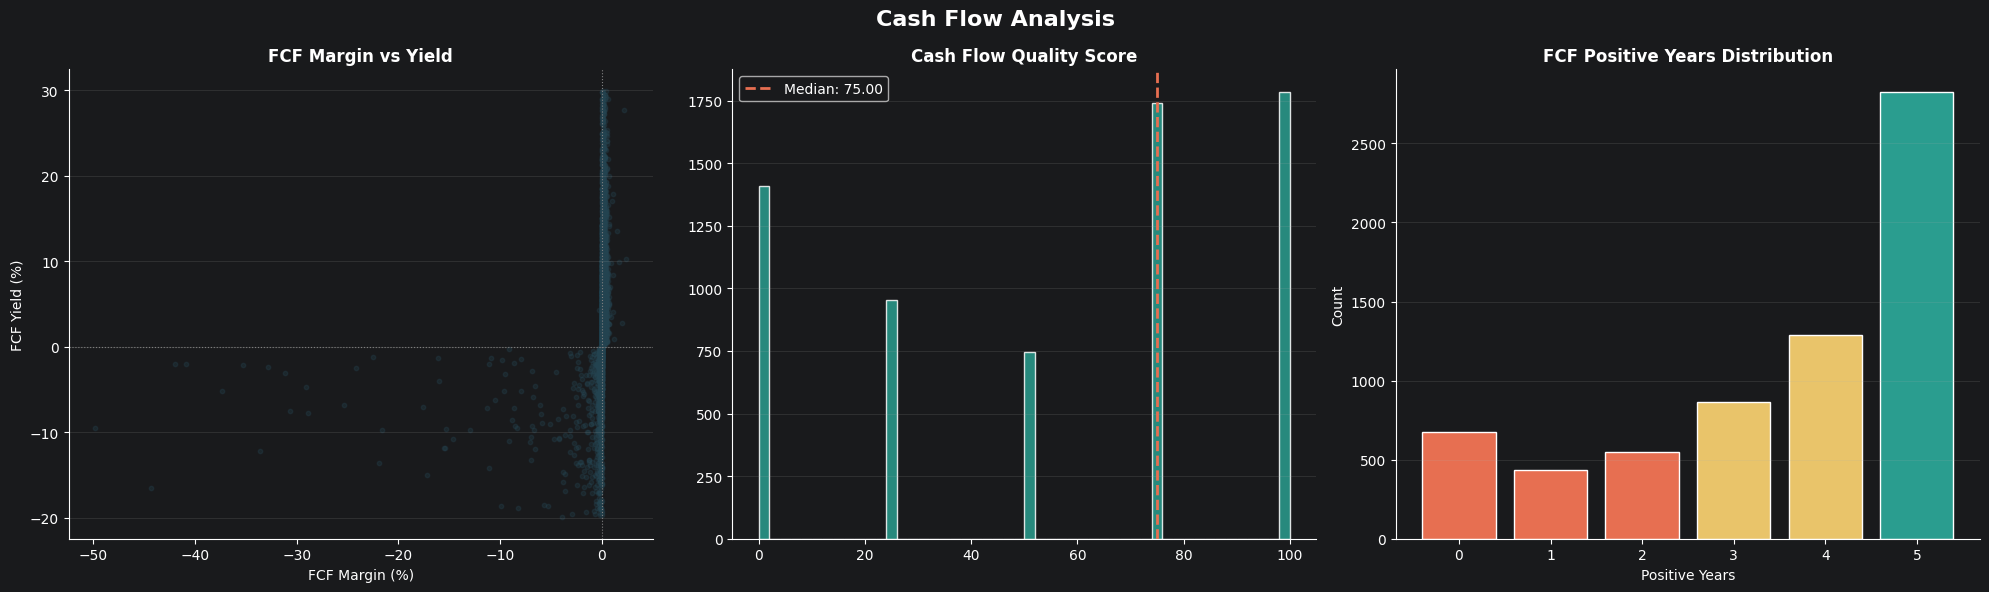

In [18]:
cf_cols = [c for c in FEATURE_CATEGORIES.get("Cash Flow", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Cash Flow Analysis", fontsize=16, fontweight="bold")

# FCF margin vs FCF yield scatter
ax = axes[0]
fcf_m = next((c for c in ["fcf_margin"] if c in df.columns), None)
fcf_y = next((c for c in ["fcf_yield"] if c in df.columns), None)
if fcf_m and fcf_y:
    valid = df[[fcf_m, fcf_y]].dropna()
    valid = valid[valid[fcf_m].between(-50, 60) & valid[fcf_y].between(-20, 30)]
    ax.scatter(valid[fcf_m], valid[fcf_y], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("FCF Margin (%)")
    ax.set_ylabel("FCF Yield (%)")
    ax.set_title("FCF Margin vs Yield", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

# Cash flow quality score
ax = axes[1]
cfq_col = next((c for c in ["cash_flow_quality_score"] if c in df.columns), None)
if cfq_col:
    cfq_data = df[cfq_col].dropna()
    ax.hist(cfq_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(cfq_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {cfq_data.median():.2f}")
    ax.set_title("Cash Flow Quality Score", fontweight="bold")
    ax.legend()

# FCF positive years distribution
ax = axes[2]
fcf_pos = next((c for c in ["fcf_positive_years"] if c in df.columns), None)
if fcf_pos:
    pos_data = df[fcf_pos].dropna()
    counts = pos_data.value_counts().sort_index()
    bar_colors = [COLORS["danger"] if v <= 2 else COLORS["accent"] if v <= 4
    else COLORS["secondary"] for v in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title("FCF Positive Years Distribution", fontweight="bold")
    ax.set_xlabel("Positive Years")
    ax.set_ylabel("Count")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Dividend Reliability Analysis

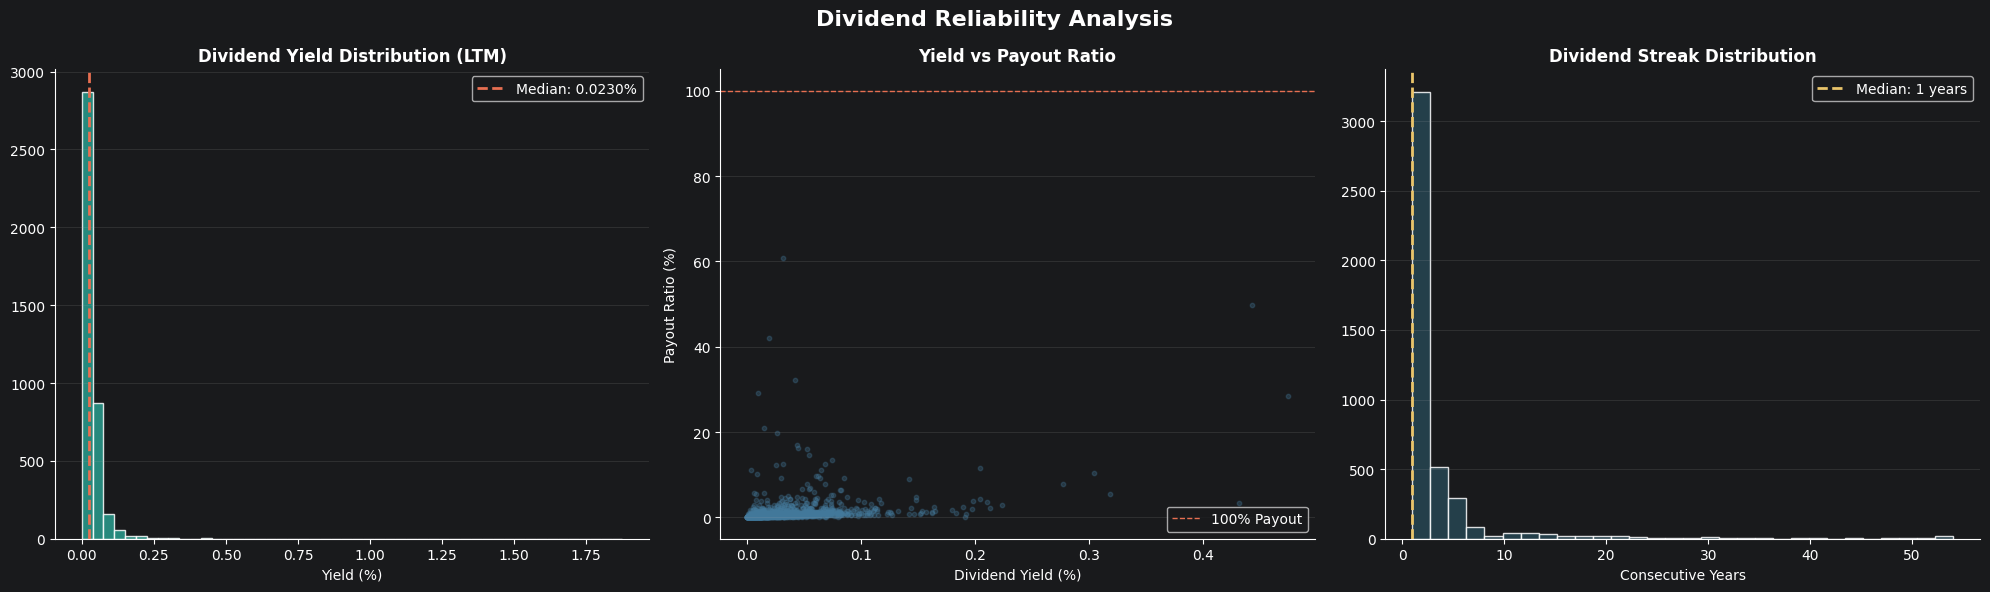

In [19]:
div_cols = [c for c in FEATURE_CATEGORIES.get("Dividend Reliability", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend Reliability Analysis", fontsize=16, fontweight="bold")

# Dividend yield distribution
ax = axes[0]
dy_col = next((c for c in ["dividend_yield_ltm"] if c in df.columns), None)
if dy_col:
    dy_data = df[dy_col].dropna()
    ax.hist(dy_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(dy_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {dy_data.median():.4f}%")
    ax.set_title("Dividend Yield Distribution (LTM)", fontweight="bold")
    ax.set_xlabel("Yield (%)")
    ax.legend()

# Dividend yield vs payout ratio
ax = axes[1]
payout_col = next((c for c in ["dividend_payout_ratio"] if c in df.columns), None)
if dy_col and payout_col:
    valid = df[[dy_col, payout_col]].dropna()
    valid = valid[(valid[dy_col] > 0) & valid[payout_col].between(0, 200)]
    ax.scatter(valid[dy_col], valid[payout_col], alpha=0.3, s=10, c=COLORS["info"])
    ax.axhline(100, color=COLORS["danger"], linestyle="--", lw=1, label="100% Payout")
    ax.set_xlabel("Dividend Yield (%)")
    ax.set_ylabel("Payout Ratio (%)")
    ax.set_title("Yield vs Payout Ratio", fontweight="bold")
    ax.legend()

# Dividend streak distribution
ax = axes[2]
streak_col = next((c for c in ["dividend_streak"] if c in df.columns), None)
if streak_col:
    streak_data = df[streak_col].dropna()
    streak_data = streak_data[streak_data > 0]
    ax.hist(streak_data, bins=30, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(streak_data.median(), color=COLORS["accent"], linestyle="--", lw=2,
               label=f"Median: {streak_data.median():.0f} years")
    ax.set_title("Dividend Streak Distribution", fontweight="bold")
    ax.set_xlabel("Consecutive Years")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Volatility Surface Analysis (Enhancement 2+3)

C:\Users\markm\AppData\Local\Temp\ipykernel_48324\1481445140.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])


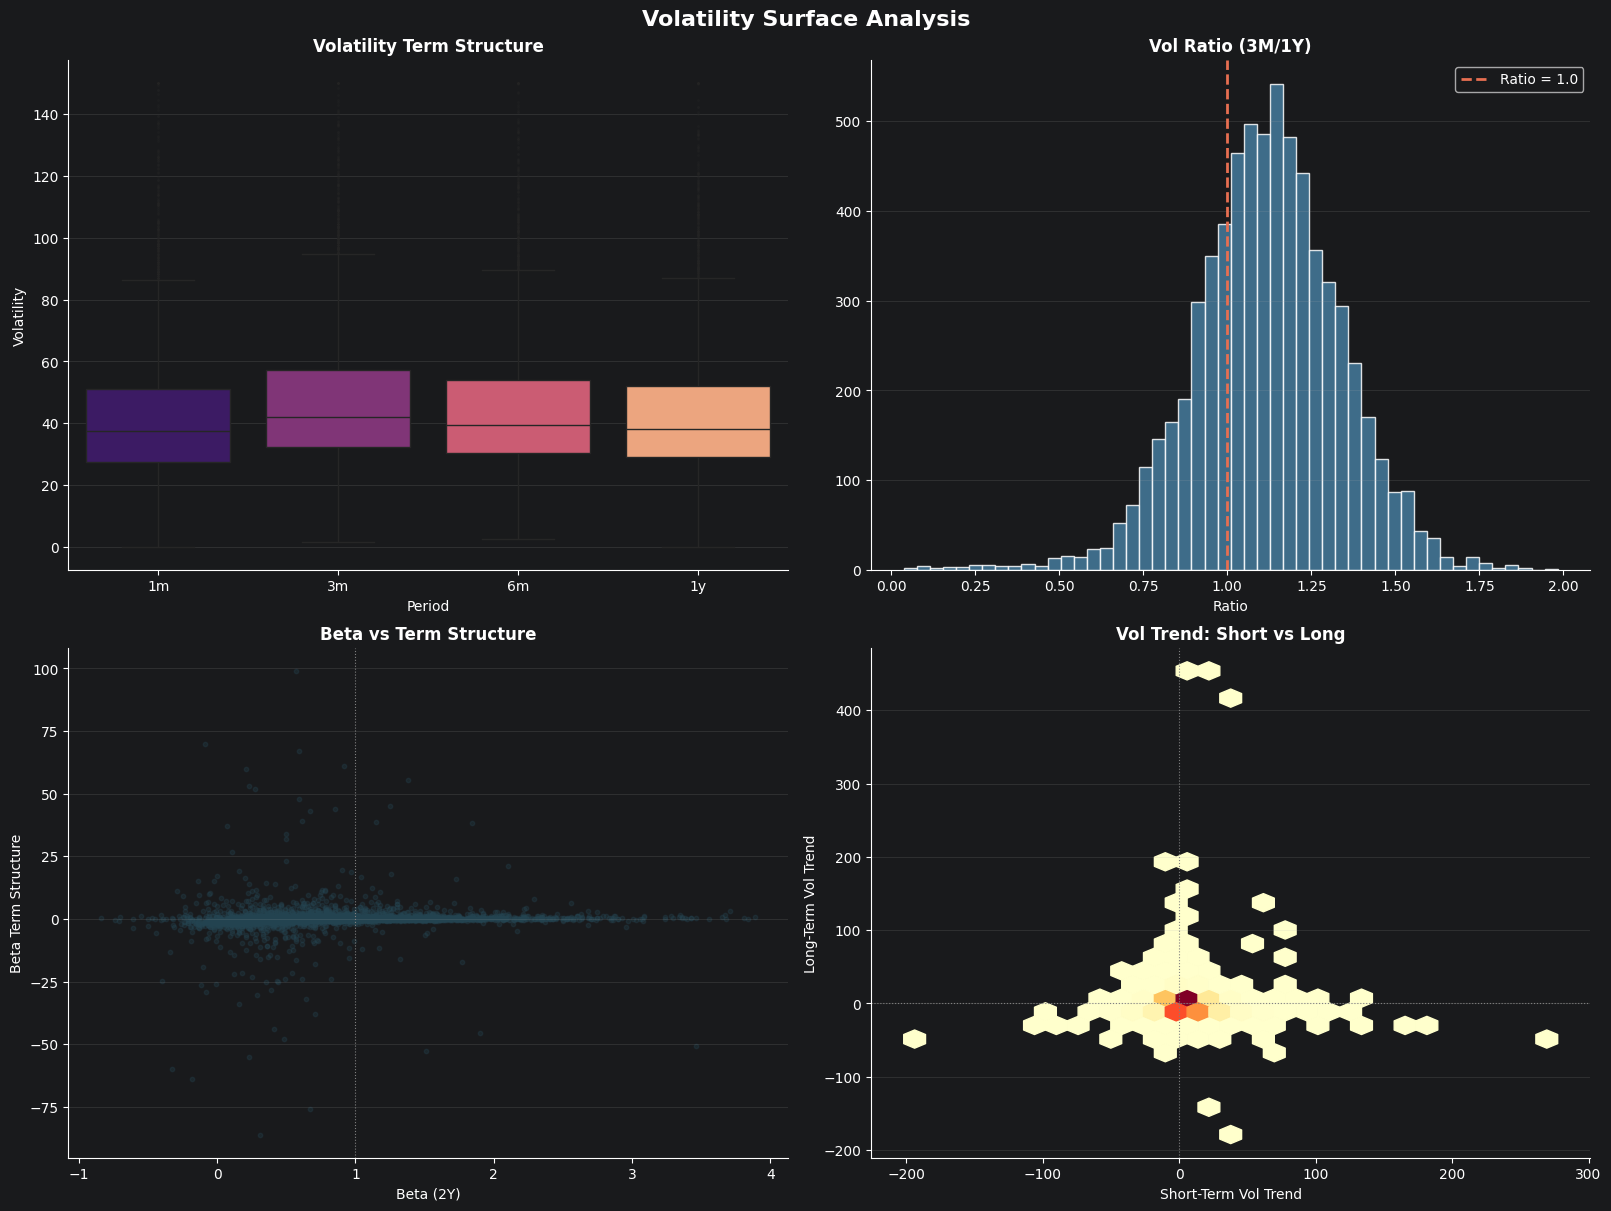

In [20]:
vol_cols = [c for c in FEATURE_CATEGORIES.get("Volatility Surface", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Volatility Surface Analysis", fontsize=16, fontweight="bold")

# Volatility term structure (box plots)
ax = axes[0, 0]
vol_term_cols = [c for c in ["volatility_1m", "volatility_3m", "volatility_6m", "volatility_1y"]
                 if c in df.columns]
if vol_term_cols:
    vol_data = df[vol_term_cols].melt(var_name="Period", value_name="Volatility")
    vol_data["Volatility"] = vol_data["Volatility"].clip(0, 150)
    sns.boxplot(data=vol_data, x="Period", y="Volatility", ax=ax, palette="magma",
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_xticklabels([c.replace("volatility_", "") for c in vol_term_cols])
    ax.set_title("Volatility Term Structure", fontweight="bold")

# Vol ratio 3M/1Y distribution
ax = axes[0, 1]
vr_col = next((c for c in ["vol_ratio_3m_1y"] if c in df.columns), None)
if vr_col:
    vr_data = df[vr_col].dropna().clip(0, 5)
    ax.hist(vr_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(1.0, color=COLORS["danger"], linestyle="--", lw=2, label="Ratio = 1.0")
    ax.set_title("Vol Ratio (3M/1Y)", fontweight="bold")
    ax.set_xlabel("Ratio")
    ax.legend()

# Beta term structure
ax = axes[1, 0]
beta_cols = [c for c in ["beta_2y", "beta_term_structure"] if c in df.columns]
if len(beta_cols) == 2:
    valid = df[beta_cols].dropna()
    valid = valid[valid[beta_cols[0]].between(-1, 4)]
    ax.scatter(valid[beta_cols[0]], valid[beta_cols[1]], alpha=0.3, s=10, c=COLORS["primary"])
    ax.set_xlabel("Beta (2Y)")
    ax.set_ylabel("Beta Term Structure")
    ax.set_title("Beta vs Term Structure", fontweight="bold")
    ax.axvline(1.0, color="grey", linestyle=":", lw=0.8)

# Volatility trend comparison
ax = axes[1, 1]
vt_short = next((c for c in ["volatility_trend_short"] if c in df.columns), None)
vt_long = next((c for c in ["volatility_trend_long"] if c in df.columns), None)
if vt_short and vt_long:
    valid = df[[vt_short, vt_long]].dropna()
    ax.hexbin(valid[vt_short], valid[vt_long], gridsize=30, cmap="YlOrRd", mincnt=1)
    ax.set_xlabel("Short-Term Vol Trend")
    ax.set_ylabel("Long-Term Vol Trend")
    ax.set_title("Vol Trend: Short vs Long", fontweight="bold")
    ax.axhline(0, color="grey", linestyle=":", lw=0.8)
    ax.axvline(0, color="grey", linestyle=":", lw=0.8)

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 15. Forward Consensus & Estimates (Enhancement 7)

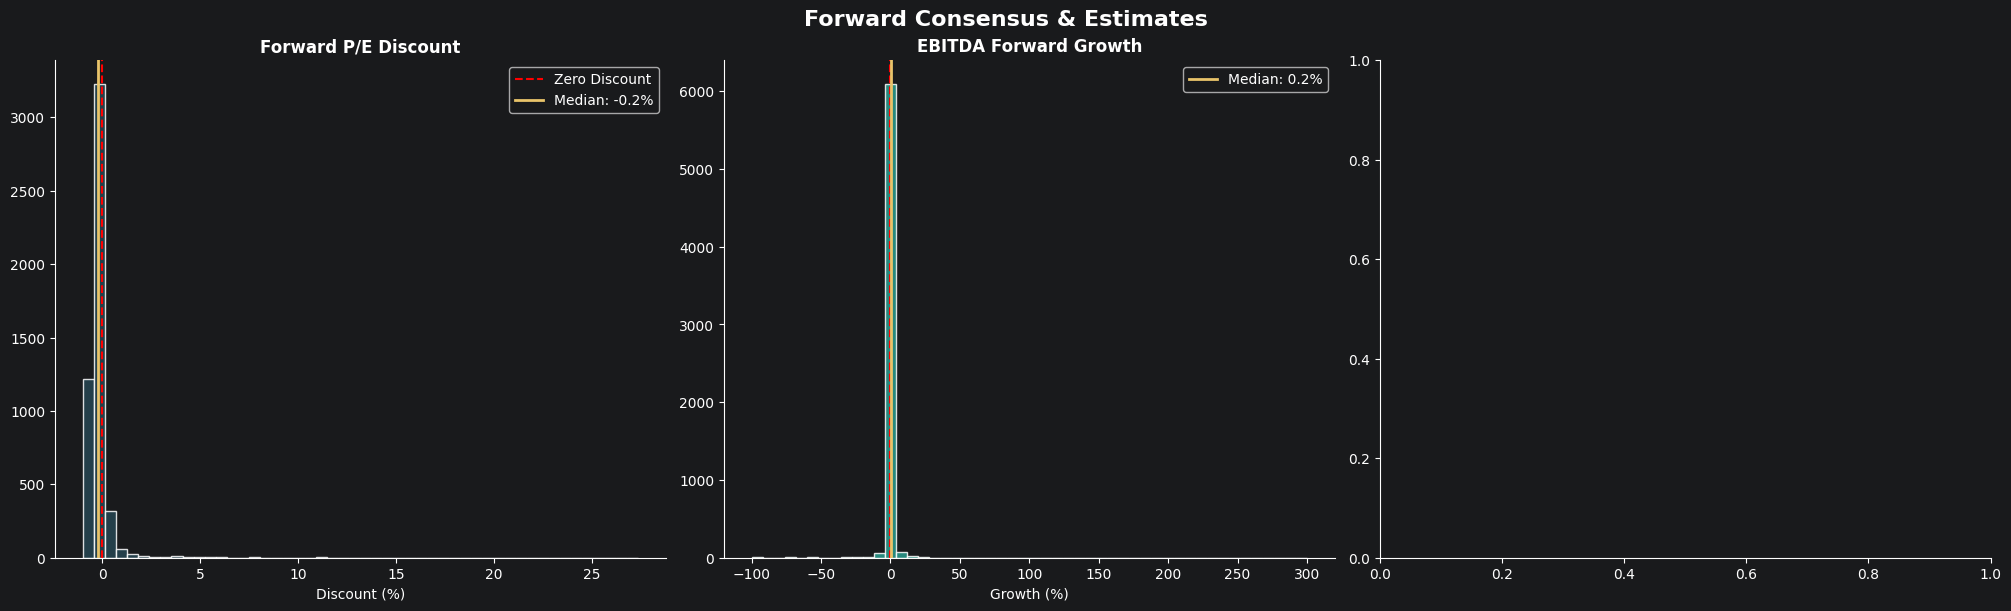

In [21]:
fwd_cols = [c for c in FEATURE_CATEGORIES.get("Forward Consensus", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Forward Consensus & Estimates", fontsize=16, fontweight="bold")

# Forward P/E discount distribution
ax = axes[0]
fpe_col = next((c for c in ["pe_forward_discount"] if c in df.columns), None)
if fpe_col:
    fpe_data = df[fpe_col].dropna().clip(-100, 100)
    ax.hist(fpe_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero Discount")
    ax.axvline(fpe_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {fpe_data.median():.1f}%")
    ax.set_title("Forward P/E Discount", fontweight="bold")
    ax.set_xlabel("Discount (%)")
    ax.legend()

# EBITDA forward growth
ax = axes[1]
ebitda_fwd = next((c for c in ["ebitda_forward_growth"] if c in df.columns), None)
if ebitda_fwd:
    ebitda_data = df[ebitda_fwd].dropna().clip(-100, 300)
    ax.hist(ebitda_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.axvline(ebitda_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {ebitda_data.median():.1f}%")
    ax.set_title("EBITDA Forward Growth", fontweight="bold")
    ax.set_xlabel("Growth (%)")
    ax.legend()

# Forward consensus correlation
ax = axes[2]
if len(fwd_cols) >= 3:
    fwd_data = df[fwd_cols].dropna(thresh=len(fwd_cols) // 2)
    if len(fwd_data) > 10:
        corr = fwd_data.corr()
        sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
                    xticklabels=[c[:14] for c in corr.columns],
                    yticklabels=[c[:14] for c in corr.columns], square=True)
        ax.set_title("Forward Consensus Correlations", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
plt.show()

## 16. Enhancement Features: Tax, OpEx, FCF Estimates, Share Dilution

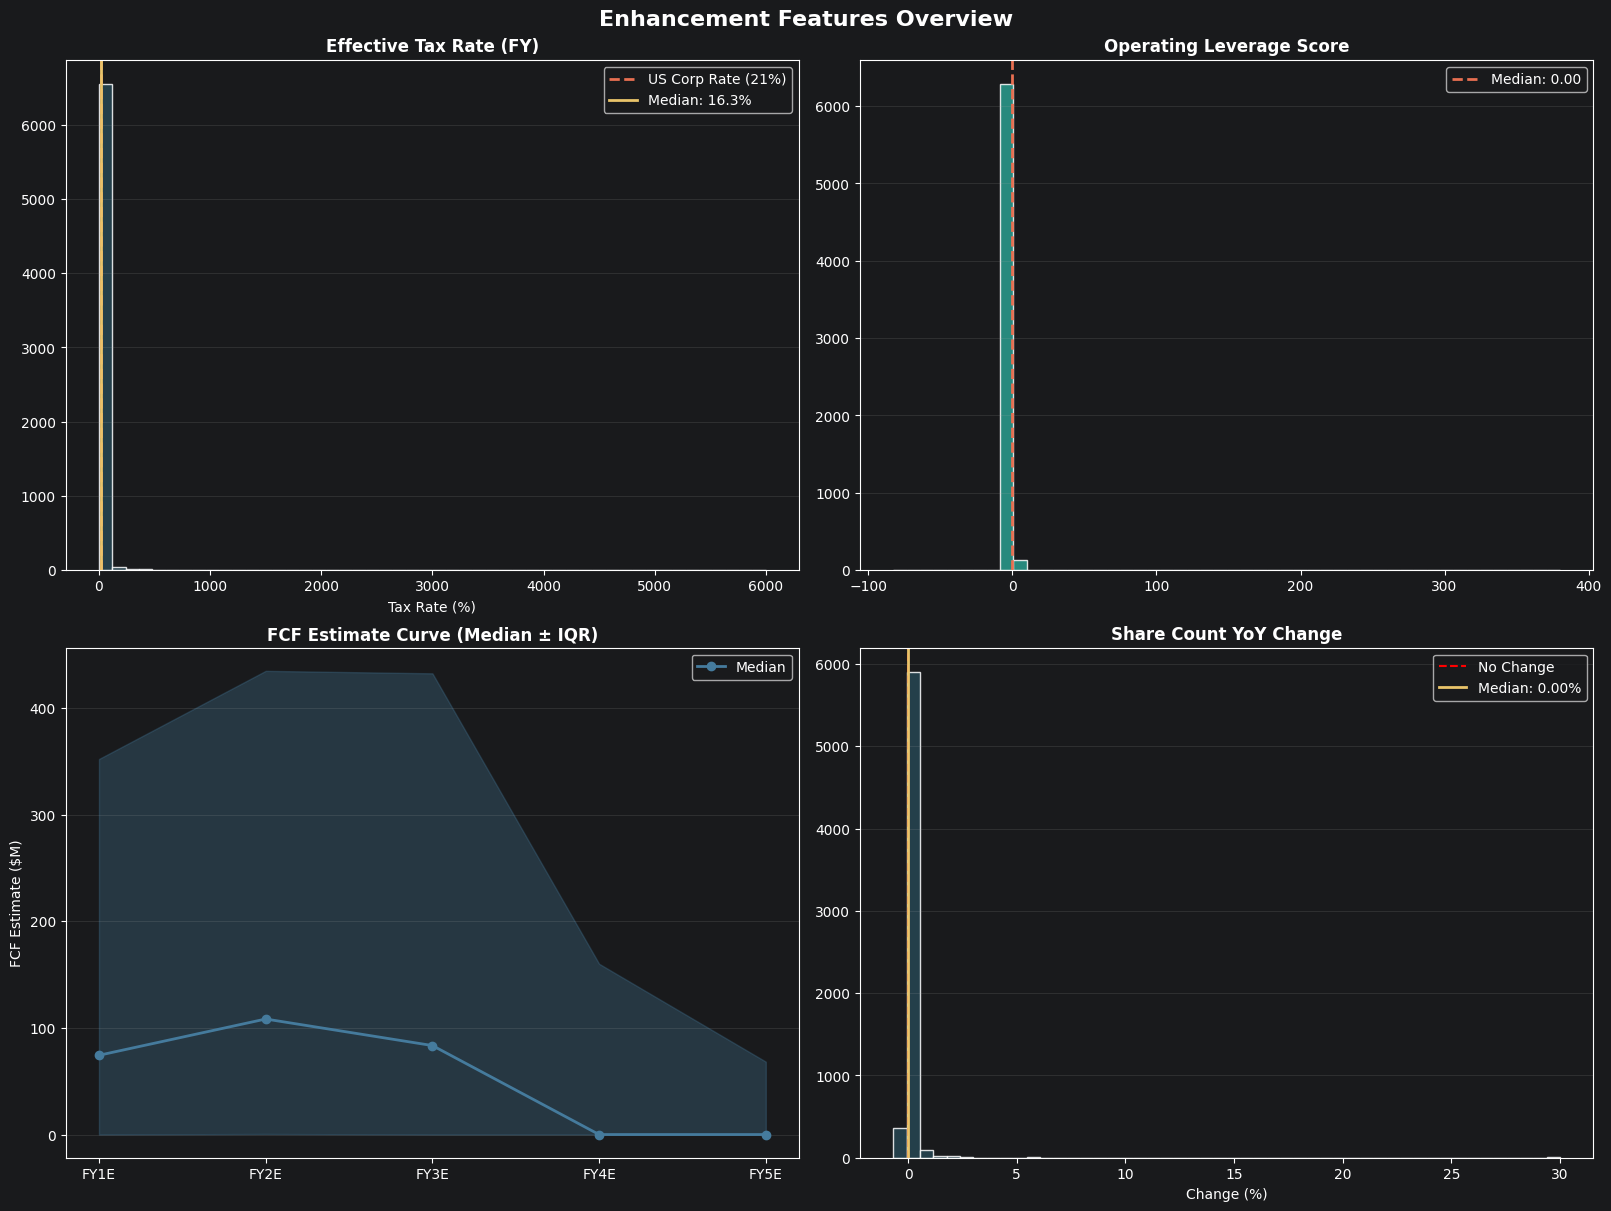

In [22]:
# Tax Rate Features (Enhancement 4)
tax_cols = [c for c in FEATURE_CATEGORIES.get("Tax Rate", []) if c in df.columns]
# OpEx Temporal (Enhancement 5)
opex_cols = [c for c in FEATURE_CATEGORIES.get("OpEx Temporal", []) if c in df.columns]
# FCF Estimates (Enhancement 9)
fcf_est_cols = [c for c in FEATURE_CATEGORIES.get("FCF Estimates", []) if c in df.columns]
# Share Dilution (Enhancement 12)
dilution_cols = [c for c in FEATURE_CATEGORIES.get("Share Dilution", []) if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Enhancement Features Overview", fontsize=16, fontweight="bold")

# Tax rate distribution
ax = axes[0, 0]
tax_col = next((c for c in ["effective_tax_rate_fy"] if c in df.columns), None)
if tax_col:
    tax_data = df[tax_col].dropna().clip(-20, 60) * 100
    ax.hist(tax_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(21, color=COLORS["danger"], linestyle="--", lw=2, label="US Corp Rate (21%)")
    ax.axvline(tax_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {tax_data.median():.1f}%")
    ax.set_title("Effective Tax Rate (FY)", fontweight="bold")
    ax.set_xlabel("Tax Rate (%)")
    ax.legend()

# OpEx operating leverage
ax = axes[0, 1]
olev_col = next((c for c in ["operating_leverage_score"] if c in df.columns), None)
if olev_col:
    olev_data = df[olev_col].dropna()
    ax.hist(olev_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(olev_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {olev_data.median():.2f}")
    ax.set_title("Operating Leverage Score", fontweight="bold")
    ax.legend()

# FCF estimate curve
ax = axes[1, 0]
fcf_fy_cols = [c for c in ["fcf_est_avg_fy1e", "fcf_est_avg_fy2e", "fcf_est_avg_fy3e",
                           "fcf_est_avg_fy4e", "fcf_est_avg_fy5e"] if c in df.columns]
if fcf_fy_cols:
    medians = [df[c].dropna().median() for c in fcf_fy_cols]
    q25 = [df[c].dropna().quantile(0.25) for c in fcf_fy_cols]
    q75 = [df[c].dropna().quantile(0.75) for c in fcf_fy_cols]
    x = range(len(fcf_fy_cols))
    ax.fill_between(x, q25, q75, alpha=0.3, color=COLORS["info"])
    ax.plot(x, medians, "o-", color=COLORS["info"], lw=2, label="Median")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["FY1E", "FY2E", "FY3E", "FY4E", "FY5E"])
    ax.set_title("FCF Estimate Curve (Median ± IQR)", fontweight="bold")
    ax.set_ylabel("FCF Estimate ($M)")
    ax.legend()

# Share dilution tracking
ax = axes[1, 1]
shares_chg = next((c for c in ["shares_yoy_change_pct"] if c in df.columns), None)
if shares_chg:
    chg_data = df[shares_chg].dropna().clip(-30, 30)
    colors_hist = [COLORS["secondary"] if v < 0 else COLORS["danger"] for v in
                   np.histogram_bin_edges(chg_data, bins=50)[:-1]]
    ax.hist(chg_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5, label="No Change")
    ax.axvline(chg_data.median(), color=COLORS["accent"], linestyle="-", lw=2,
               label=f"Median: {chg_data.median():.2f}%")
    ax.set_title("Share Count YoY Change", fontweight="bold")
    ax.set_xlabel("Change (%)")
    ax.legend()

for a in axes.flat:
    a.spines["top"].set_visible(True)
    a.spines["right"].set_visible(True)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 17. Dividend History & Asset Sales (Enhancements 8, 10)

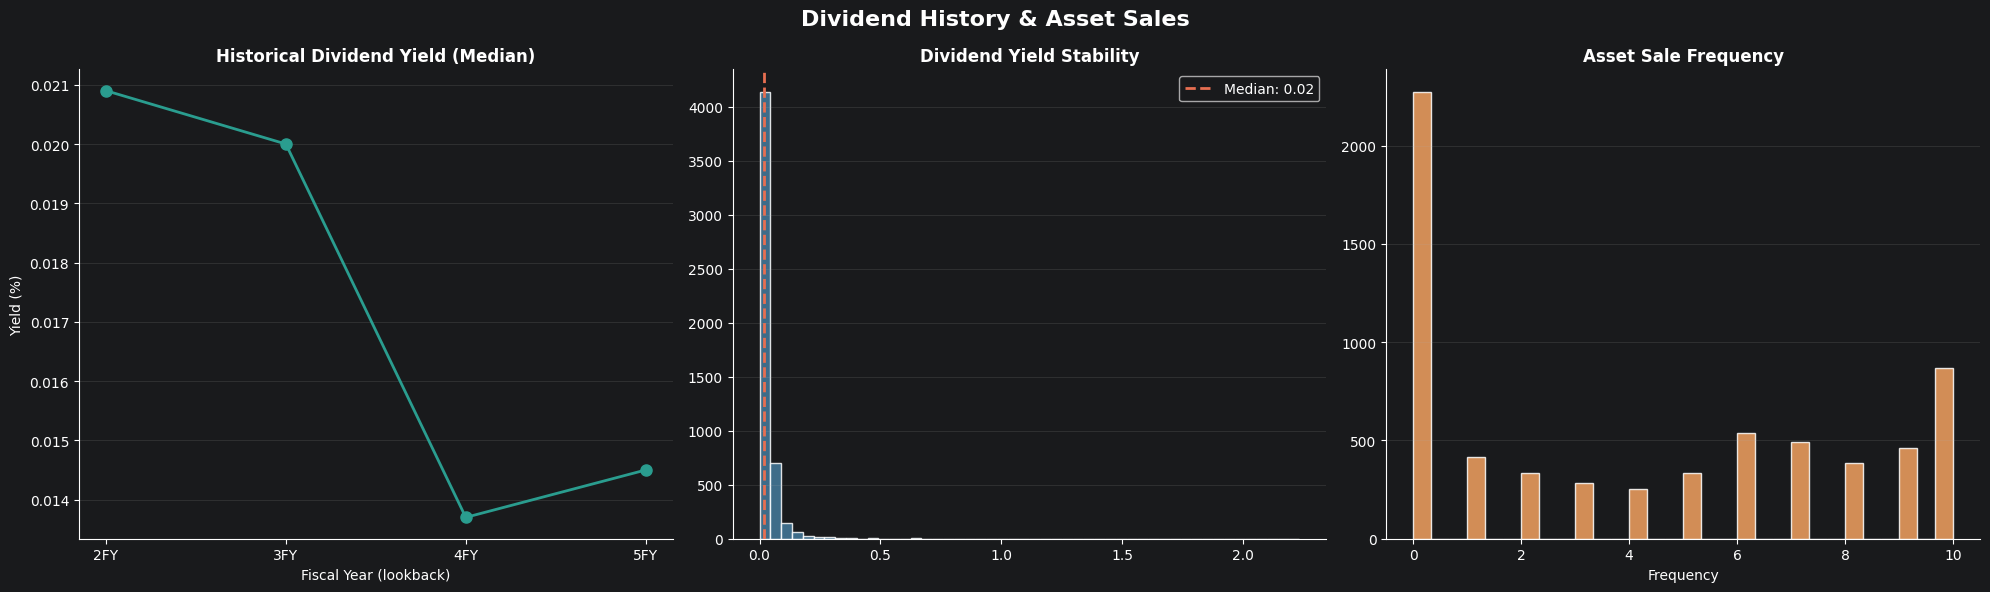

In [23]:
div_hist_cols = [c for c in FEATURE_CATEGORIES.get("Dividend History", []) if c in df.columns]
asset_cols = [c for c in FEATURE_CATEGORIES.get("Asset Sales", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dividend History & Asset Sales", fontsize=16, fontweight="bold")

# Dividend yield history trend
ax = axes[0]
dy_hist_cols = [c for c in ["div_yield_2fyind", "div_yield_3fyind", "div_yield_4fyind",
                            "div_yield_5fyind"] if c in df.columns]
if dy_hist_cols:
    medians = [df[c].dropna().median() for c in dy_hist_cols]
    ax.plot(range(len(dy_hist_cols)), medians, "o-", color=COLORS["secondary"], lw=2, markersize=8)
    ax.set_xticks(range(len(dy_hist_cols)))
    ax.set_xticklabels(["2FY", "3FY", "4FY", "5FY"])
    ax.set_title("Historical Dividend Yield (Median)", fontweight="bold")
    ax.set_ylabel("Yield (%)")
    ax.set_xlabel("Fiscal Year (lookback)")

# Dividend yield stability
ax = axes[1]
stab_col = next((c for c in ["div_yield_stability"] if c in df.columns), None)
if stab_col:
    stab_data = df[stab_col].dropna()
    ax.hist(stab_data, bins=50, color=COLORS["info"], alpha=0.85, edgecolor="white")
    ax.axvline(stab_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: {stab_data.median():.2f}")
    ax.set_title("Dividend Yield Stability", fontweight="bold")
    ax.legend()

# Asset sale frequency
ax = axes[2]
asf_col = next((c for c in ["asset_sale_frequency"] if c in df.columns), None)
if asf_col:
    asf_data = df[asf_col].dropna()
    ax.hist(asf_data, bins=30, color=COLORS["light"], alpha=0.85, edgecolor="white")
    ax.set_title("Asset Sale Frequency", fontweight="bold")
    ax.set_xlabel("Frequency")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 18. Interest Income & Employee Productivity (Enhancements 11)

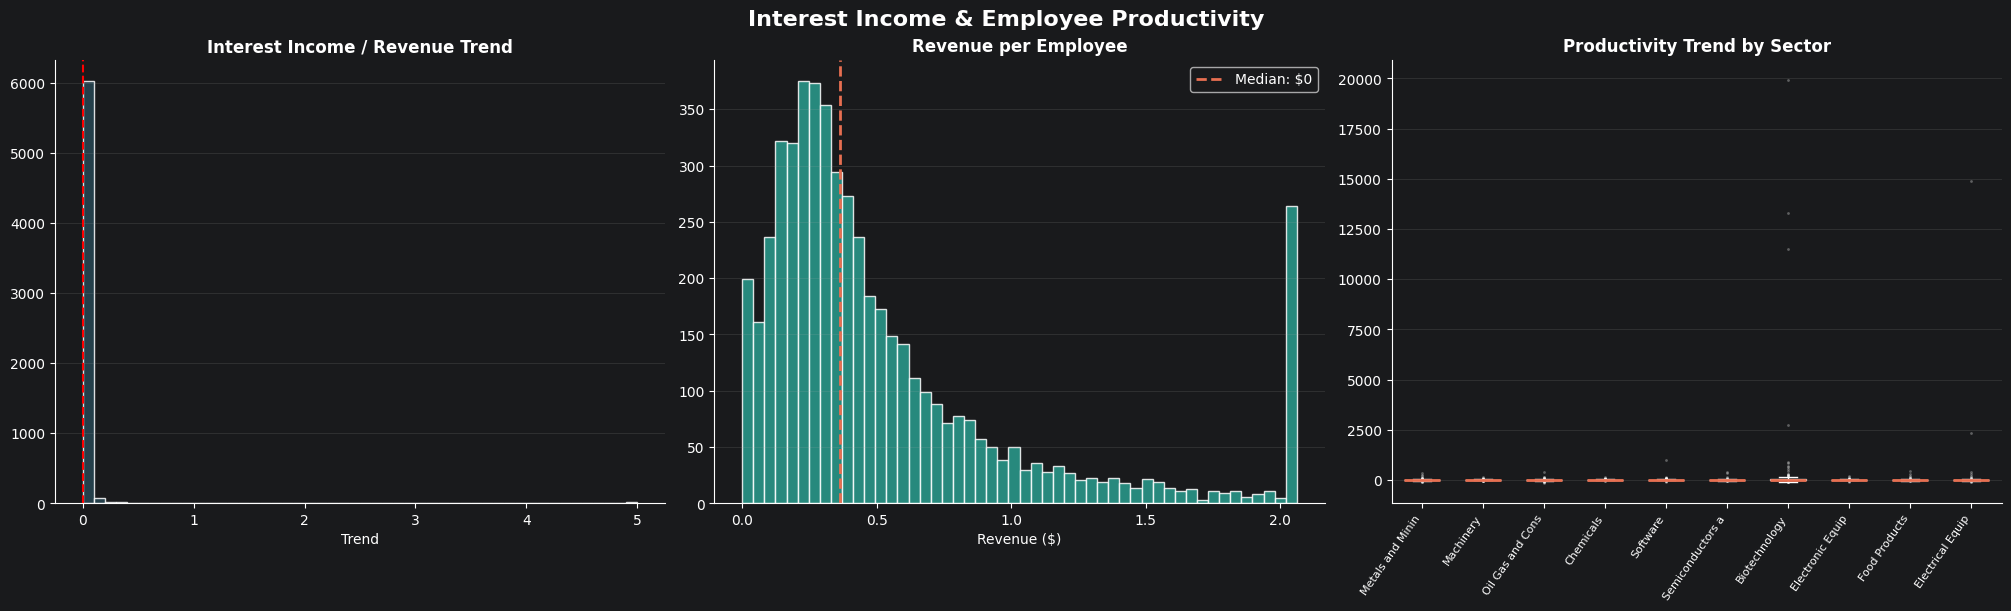

In [24]:
int_cols = [c for c in FEATURE_CATEGORIES.get("Interest Income Temporal", []) if c in df.columns]
emp_cols = [c for c in FEATURE_CATEGORIES.get("Employee Productivity", []) if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")
fig.suptitle("Interest Income & Employee Productivity", fontsize=16, fontweight="bold")

# Interest income to revenue trend
ax = axes[0]
ii_col = next((c for c in ["interest_income_to_revenue_trend"] if c in df.columns), None)
if ii_col:
    ii_data = df[ii_col].dropna().clip(-5, 5)
    ax.hist(ii_data, bins=50, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.set_title("Interest Income / Revenue Trend", fontweight="bold")
    ax.set_xlabel("Trend")

# Revenue per employee
ax = axes[1]
rpe_col = next((c for c in ["revenue_per_employee"] if c in df.columns), None)
if rpe_col:
    rpe_data = df[rpe_col].dropna().clip(0, df[rpe_col].dropna().quantile(0.95))
    ax.hist(rpe_data, bins=50, color=COLORS["secondary"], alpha=0.85, edgecolor="white")
    ax.axvline(rpe_data.median(), color=COLORS["danger"], linestyle="--", lw=2,
               label=f"Median: ${rpe_data.median():,.0f}")
    ax.set_title("Revenue per Employee", fontweight="bold")
    ax.set_xlabel("Revenue ($)")
    ax.legend()

# Productivity trend by sector
ax = axes[2]
prod_col = next((c for c in ["productivity_trend"] if c in df.columns), None)
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if prod_col and sector_col:
    sectors = df[sector_col].value_counts().head(10).index
    prod_data = [df.loc[df[sector_col] == s, prod_col].dropna().values for s in sectors]
    bp = ax.boxplot(prod_data, vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color=COLORS["danger"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    box_colors = plt.cm.Set3(np.linspace(0, 1, len(sectors)))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_xticklabels([s[:16] for s in sectors], rotation=55, ha="right", fontsize=8)
    ax.set_title("Productivity Trend by Sector", fontweight="bold")

for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(axis="y", alpha=0.2)
plt.show()

## 19. Cross-Category Correlation Analysis

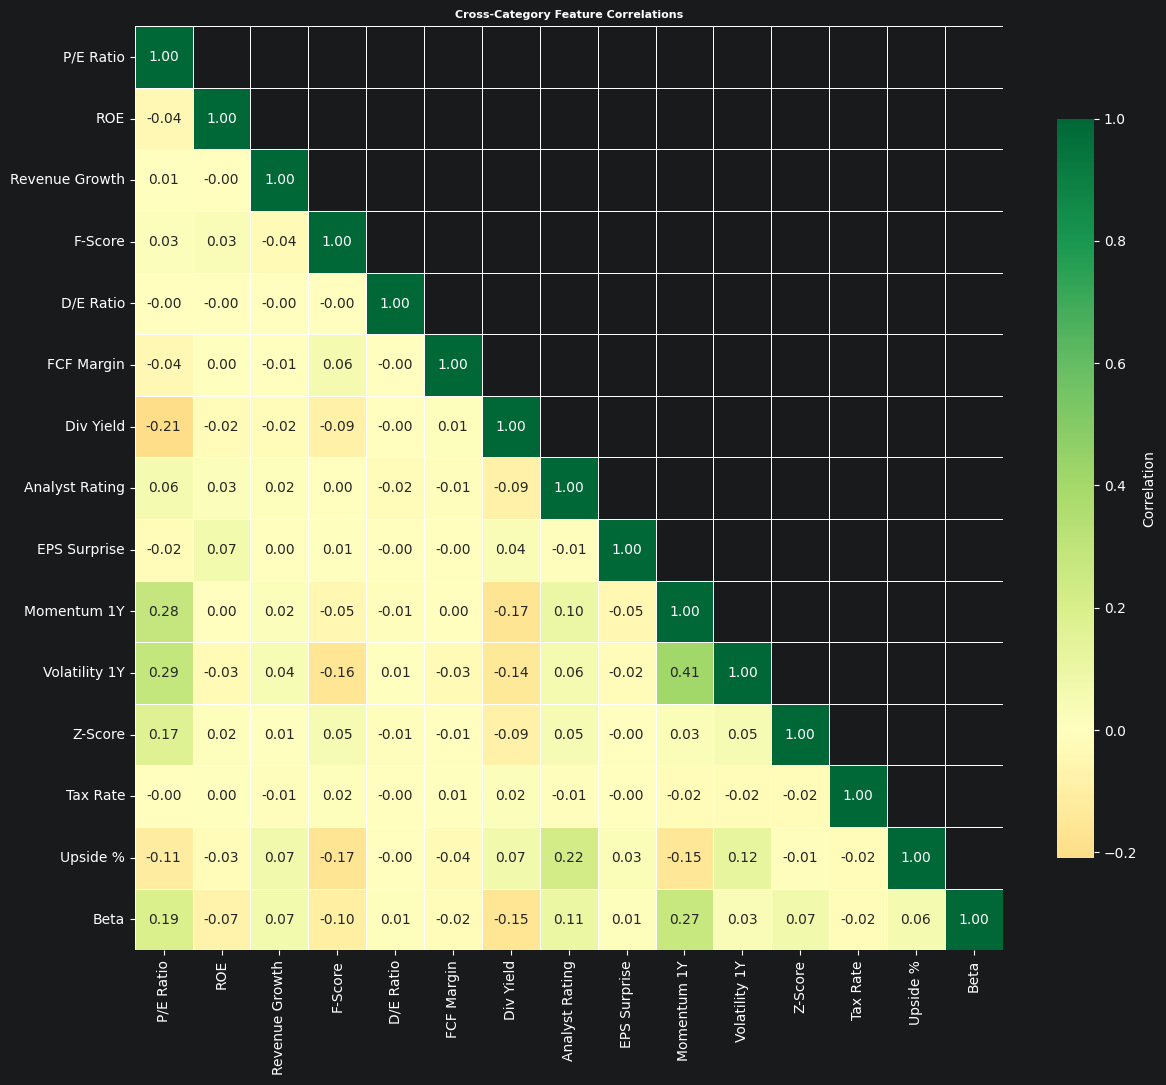

In [25]:
# Select one representative feature per category for the master correlation matrix
representative_features = {
    "P/E Ratio": "p_e_ratio",
    "ROE": "roe",
    "Revenue Growth": "revenue_growth_yoy",
    "F-Score": "piotroski_f_score",
    "D/E Ratio": "debt_to_equity",
    "FCF Margin": "fcf_margin",
    "Div Yield": "dividend_yield_ltm",
    "Analyst Rating": "analyst_rating_normalized",
    "EPS Surprise": "eps_surprise_pct",
    "Momentum 1Y": "price_momentum_1y",
    "Volatility 1Y": "volatility_1y",
    "Z-Score": "altman_z_score",
    "Tax Rate": "effective_tax_rate_fy",
    "Upside %": "upside_potential",
    "Beta": "beta_2y",
}

available_rep = {k: v for k, v in representative_features.items() if v in df.columns}
rep_df = df[list(available_rep.values())].dropna(thresh=len(available_rep) // 2)

fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=False)
corr = rep_df.corr()
corr.columns = list(available_rep.keys())
corr.index = list(available_rep.keys())
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=ax, square=False, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
ax.set_title("Cross-Category Feature Correlations", fontsize=8, fontweight="bold")
plt.show()

## 20. Stock Screening Results

In [26]:
# Enhanced screener: high-quality stocks
quality_stocks = create_enhanced_screener(df, min_fscore=7)
print(f"Enhanced Screener (F-Score ≥ 7): {len(quality_stocks)} stocks")
if len(quality_stocks) > 0:
    display_cols = [c for c in
                    ["isin", "name", "industry", "piotroski_f_score", "last_price", "price_target", 'p_e_ratio',
                     'peg_ratio', "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy", "altman_z_score",
                     "upside_potential", "eps_trajectory_score"] if c in quality_stocks.columns]
    display(quality_stocks[display_cols].head(50))

Enhanced Screener (F-Score ≥ 7): 47 stocks


,isin,name,industry,piotroski_f_score,last_price,price_target,p_e_ratio,peg_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,altman_z_score,upside_potential,eps_trajectory_score
31,US5128073062,Lam Research Corporation,Semiconductors and Semiconductor Equipment,9,257.8600,310.8064,62.1000,7.5534,-0.4444,-26.8921,1.5244,15.2700,22.1593,80
596,US7512121010,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,9,358.6400,412.0750,30.9000,2.3715,-0.3398,-28.8026,0.2929,5.4000,19.7580,60
1157,US1096411004,Brinker International Inc.,Hotels Restaurants and Leisure,9,152.2400,186.7273,18.3000,0.3783,-0.2951,-22.4044,-0.0368,NaN,24.4745,60
4363,JP3148800000,Ibiden Co.Ltd.,Electronic Equipment Instruments and Components,9,13480.0000,9523.5294,114.2000,-8.8642,-0.4606,-21.3660,3.0641,2.4100,-28.7834,80
5226,JP3110650003,Asahi Intecc Co. Ltd.,Health Care Equipment and Supplies,9,3298.0000,3829.3333,64.7000,14.7007,-0.5626,-54.0958,0.4283,13.2200,21.2856,60
4020,TW0002308004,Delta Electronics Inc.,Electronic Equipment Instruments and Components,9,2165.0000,2182.2632,93.2000,4.2843,-0.4957,-43.7768,0.5032,5.9300,11.7783,80
95,US5951121038,Micron Technology Inc.,Semiconductors and Semiconductor Equipment,8,517.1600,551.4048,68.1000,-99.0398,-0.9178,-86.9310,1.7571,6.9400,6.1567,80
1047,US1727551004,Cirrus Logic Inc.,Semiconductors and Semiconductor Equipment,8,163.0800,160.0000,27.2000,8.8799,-0.3493,-33.8235,0.6386,11.7200,2.7103,80
1796,US6304021057,Napco Security Technologies Inc.,Electronic Equipment Instruments and Components,8,46.7500,49.6667,39.3000,1.2551,-0.2163,-19.0840,0.3887,29.2600,5.8824,80
4566,CNE000000VG9,Yunnan Aluminium Co. Ltd.,Metals and Mining,8,31.8000,37.4750,18.6000,1.9417,-0.4839,-49.4624,0.1341,8.6200,22.4843,80


In [27]:
# Value opportunities
value_stocks = screen_value_opportunities(df)
print(f"\nValue Opportunities: {len(value_stocks)} stocks")
if len(value_stocks) > 0:
    display_cols = [c for c in
                    ["isin", "name", "p_e_ratio", "pe_forward_discount", "forward_pe_premium", "p_e_momentum_yoy",
                     "upside_potential",
                     "price_to_tangible_book"] if c in value_stocks.columns]
    display(value_stocks[display_cols].head(50))


Value Opportunities: 1369 stocks


,isin,name,p_e_ratio,pe_forward_discount,forward_pe_premium,p_e_momentum_yoy,upside_potential,price_to_tangible_book
5,US30231G1022,Exxon Mobil Corporation,23.0000,-0.3348,-33.4783,0.0222,6.9138,2.5000
17,US1667641005,Chevron Corporation,29.2000,-0.4623,-46.2329,0.0429,11.7376,2.1000
23,US91324P1021,UnitedHealth Group Incorporated,28.0000,-0.3000,-27.8571,0.2556,7.9680,3.2000
30,PLAMBRA00013,Ambra S.A.,10.7000,-0.2056,-13.0841,-0.0446,23.6842,1.4000
35,US01609W1027,Alibaba Group Holding Limited,17.9000,0.1397,48.6034,0.2177,41.7749,2.7000
40,US88642R1095,Tidewater Inc.,13.5000,0.6296,62.9630,0.1250,-7.0861,3.2000
42,DE000A0N4N52,NFON AG,25.1000,-0.3506,-35.0598,-0.0079,142.6901,4.8000
49,PLFORTE00012,Fabryki Mebli FORTE S.A.,10.1000,-0.0396,-40.5941,-0.2786,44.1103,0.5000
73,US48563L1017,Karat Packaging Inc.,18.4000,-0.2283,-22.8261,0.0636,2.8233,3.9000
90,GRS470003013,Piraeus Port Authority S.A.,10.9000,NaN,NaN,0.0381,32.4503,2.1000


In [28]:
# Growth momentum stocks
growth_stocks = screen_growth_momentum(df)
print(f"\nGrowth Momentum: {len(growth_stocks)} stocks")
if len(growth_stocks) > 5:
    display_cols = [c for c in ["isin", "name", "revenue_growth_yoy",
                                "eps_yoy_growth", "price_momentum_1y", "eps_momentum_yoy"] if
                    c in growth_stocks.columns]
    display(growth_stocks[display_cols].head(50))


Growth Momentum: 2797 stocks


,isin,name,revenue_growth_yoy,eps_yoy_growth,price_momentum_1y
4307,ARTRAN010011,Compañía de Transporte de Energía Eléctrica en...,19.6933,100.0000,84.7619
38,US03823U1025,Applied Optoelectronics Inc.,82.7445,85.7778,1185.0665
4109,JP3811000003,Fujikura Ltd.,23.5968,85.0000,544.8164
4131,TW0006442007,EZconn Corporation,71.8979,70.4545,494.3662
4598,TW0006223001,MPI Corporation,37.5969,44.5946,656.5284
4274,KR7267260008,HD Hyundai Electric Co. Ltd.,25.6073,49.3644,307.1545
1809,CA88034V3048,Tenaz Energy Corp.,415.5915,4170.0000,328.2623
1662,US05614L2097,Babcock & Wilcox Enterprises Inc.,1.1428,41.4634,3372.2838
6071,TRAASELS91H2,ASELSAN Elektronik Sanayi ve Ticaret Anonim Si...,23.7036,66.6667,211.2963
179,US1468691027,Carvana Co.,48.6287,494.1860,61.9808


In [29]:
# Dividend quality stocks
div_stocks = screen_dividend_quality(df)
print(f"\nDividend Quality: {len(div_stocks)} stocks")
if len(div_stocks) > 0:
    display_cols = [c for c in ["isin", "name", "dividend_yield_ltm",
                                "dividend_streak", "fcf_dividend_coverage"] if c in div_stocks.columns]
    display(div_stocks[display_cols].head(50))


Dividend Quality: 519 stocks


,isin,name,dividend_yield_ltm,dividend_streak,fcf_dividend_coverage
4783,INE205A01025,Vedanta Limited,0.1271,0,1.4024
6544,BREVENACNOR8,Even Construtora e Incorporadora S.A.,0.1111,2,0.5924
1143,US2058871029,Conagra Brands Inc.,0.0975,1,1.2582
5655,ID1000095706,PT Unilever Indonesia Tbk,0.0909,2,0.9682
6505,BRCSEDACNOR9,Cruzeiro do Sul Educacional S.A.,0.0817,0,4.3807
1836,US76009N1000,Upbound Group Inc.,0.0762,8,2.7169
3417,NO0013135368,Solstad Maritime ASA,0.0747,0,1.5525
3310,NO0003921009,DNO ASA,0.0727,6,0.6806
3284,NO0010716582,Aker Solutions ASA,0.0716,3,1.3709
1618,US5007541064,The Kraft Heinz Company,0.0706,1,1.9289


In [30]:
# Financially healthy stocks
healthy_stocks = screen_financial_health(df)
print(f"\nFinancial Health: {len(healthy_stocks)} stocks")
if len(healthy_stocks) > 0:
    display_cols = [c for c in ["isin", "name", "altman_z_score", "piotroski_f_score",
                                "current_ratio", "interest_coverage"] if c in healthy_stocks.columns]
    display(healthy_stocks[display_cols].head(50))


Financial Health: 959 stocks


,isin,name,altman_z_score,piotroski_f_score,current_ratio,interest_coverage
6632,NO0003058109,Nordic Halibut AS,NaN,1,2.0000,-0.4811
6,NL0012817175,Alfen N.V.,3.2300,3,1.9000,-1.7340
28,GB00BW9PJQ87,Gear4music (Holdings) plc,3.1500,7,2.2000,-4.4605
36,US0080642061,Jade Biosciences Inc.,NaN,1,21.1000,31.5389
6606,TREMDTR00028,Meditera Tibbi Malzeme Sanayi ve Ticaret Anoni...,5.3600,4,3.4000,-2.2545
6596,TN0007720014,Unité de Fabrication des Médicaments S.A,3.7900,9,2.2000,-5.6170
46,FR0014003VY4,Hydrogène de France Société anonyme,NaN,2,8.7000,49.6667
49,PLFORTE00012,Fabryki Mebli FORTE S.A.,3.0500,7,2.5000,-6.2388
6593,BRVITTACNOR4,Vittia S.A.,3.2100,4,2.7000,-2.8513
82,GB0008237132,Solid State plc,3.6500,6,2.1000,-5.6503


## 21. Composite Rankings

Ranked 6635 stocks by composite score

Top 50 by Composite Score:


,isin,name,industry,composite_score
1157,US1096411004,Brinker International Inc.,Hotels Restaurants and Leisure,100.0000
596,US7512121010,Ralph Lauren Corporation,Textiles Apparel and Luxury Goods,100.0000
89,US0378331005,Apple Inc.,Technology Hardware Storage and Peripherals,97.5000
4020,TW0002308004,Delta Electronics Inc.,Electronic Equipment Instruments and Components,97.5000
1455,US5006432000,Korn Ferry,Professional Services,97.5000
31,US5128073062,Lam Research Corporation,Semiconductors and Semiconductor Equipment,97.5000
462,US1475281036,Casey's General Stores Inc.,Consumer Staples Distribution and Retail,97.2222
260,US1999081045,Comfort Systems USA Inc.,Construction and Engineering,97.2222
3493,SE0008014476,Plejd AB (publ),Electrical Equipment,97.2222
103,CA8911021050,Toromont Industries Ltd.,Trading Companies and Distributors,94.7222


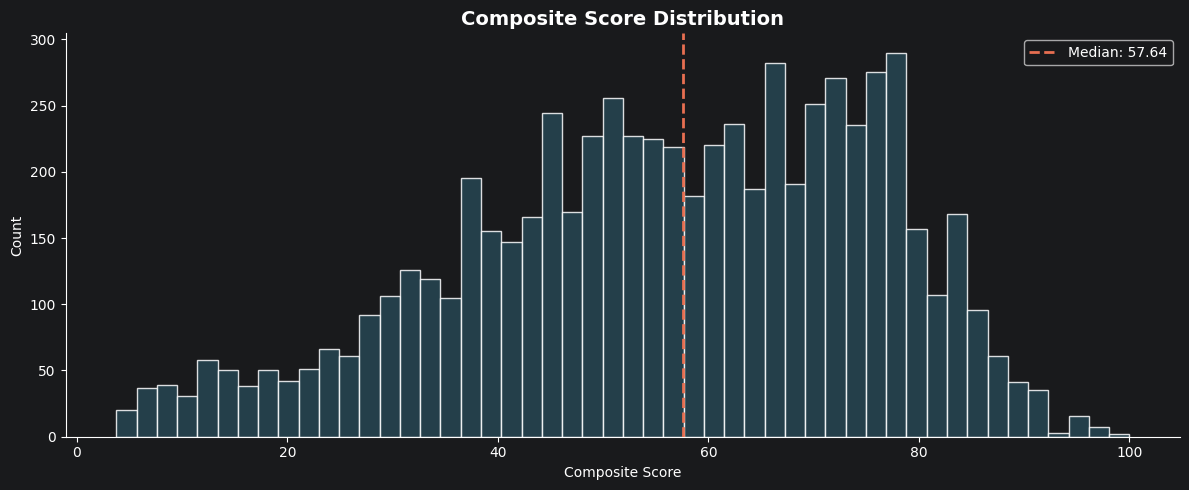

In [31]:
# Rank stocks by composite score
ranked_df = rank_stocks_by_composite_score(df)
print(f"Ranked {len(ranked_df)} stocks by composite score")
if "composite_score" in ranked_df.columns:
    display_cols = [c for c in ["isin", "name", "industry", "composite_score"]
                    if c in ranked_df.columns]
    print("\nTop 50 by Composite Score:")
    display(ranked_df[display_cols].head(50))

    # Composite score distribution
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(ranked_df["composite_score"].dropna(), bins=50, color=COLORS["primary"],
            alpha=0.85, edgecolor="white")
    ax.axvline(ranked_df["composite_score"].median(), color=COLORS["danger"],
               linestyle="--", lw=2, label=f"Median: {ranked_df['composite_score'].median():.2f}")
    ax.set_title("Composite Score Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel("Composite Score")
    ax.set_ylabel("Count")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

## 22. Statistical Analysis: Bayesian Category Analysis

In [32]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

# Build a set of features with "direct" calculation_type to exclude
direct_features = set(
    feature_cat.loc[feature_cat["calculation_type"] == "direct", "feature_alias"].tolist()
)
print(f"Excluding {len(direct_features)} features with calculation_type='direct'")

for cat_name, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Bayesian Analysis: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = bayesian_category_analysis(df, cat_name, available)
        if isinstance(result, dict):
            for feat, stats in result.items():
                if isinstance(stats, dict):
                    print(f"\n  {feat}:")
                    for k, v in stats.items():
                        if isinstance(v, (int, float)):
                            print(f"    {k}: {v:.4f}")
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")

Excluding 405 features with calculation_type='direct'

  Bayesian Analysis: Accounting Quality (20 features)

  asset_sale_frequency:
    n_obs: 6635.0000
    sample_mean: 4.0981
    sample_std: 3.8338
    posterior_mean: 4.0980
    posterior_std: 0.0471
    ci_95_low: 4.0058
    ci_95_high: 4.1903
    prob_positive: 1.0000

  asset_sale_trend:
    n_obs: 6635.0000
    sample_mean: -2.8519
    sample_std: 177.7671
    posterior_mean: -2.7223
    posterior_std: 2.1322
    ci_95_low: -6.9014
    ci_95_high: 1.4568
    prob_positive: 0.1008

  tax_rate_yoy_change:
    n_obs: 6635.0000
    sample_mean: -0.0810
    sample_std: 4.7692
    posterior_mean: -0.0810
    posterior_std: 0.0585
    ci_95_low: -0.1958
    ci_95_high: 0.0337
    prob_positive: 0.0831

  tax_rate_qoq_change:
    n_obs: 6635.0000
    sample_mean: -0.0198
    sample_std: 1.6166
    posterior_mean: -0.0198
    posterior_std: 0.0198
    ci_95_low: -0.0587
    ci_95_high: 0.0191
    prob_positive: 0.1590

  tax_rate_stabil

## 23. Distribution Fitting by Category

In [33]:
# Fit statistical distributions to ALL feature categories
# (reuses the same direct_features exclusion set built in cell 22)

for cat_name, features in FEATURE_CATEGORIES.items():
    available = [f for f in features if f in df.columns and f not in direct_features]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Distribution Fitting: {cat_name} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = fit_distributions_by_category(df, cat_name, available, n_simulations=500)
        if isinstance(result, dict):
            for feat, info in result.items():
                if isinstance(info, dict) and "best_distribution" in info:
                    print(
                        f"  {feat}: best_distribution={info['best_distribution']}, "
                        f"aic={info.get('aic', 'N/A'):.4f}, "
                        f"params={info.get('params', 'N/A')}, "
                        f"simulated_mean={info.get('simulated_mean', 'N/A'):.4f}, "
                        f"simulated_std={info.get('simulated_std', 'N/A'):.4f}, "
                        f"cvar_5_pct={info.get('cvar_5_pct', 'N/A'):.4f}"
                    )
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {cat_name}: {skipped_reason}")


  Distribution Fitting: Accounting Quality (20 features)
  asset_sale_frequency: best_distribution=skew_normal, aic=32525.9069, params=(np.float64(12297122.446249511), np.float64(-2.423176346095261e-06), np.float64(5.6119129403740775)), simulated_mean=4.5619, simulated_std=3.5073, cvar_5_pct=0.1309
  asset_sale_trend: best_distribution=skew_normal, aic=44115.2115, params=(np.float64(-1.080667651906194), np.float64(4.687070981848294), np.float64(8.914443481215274)), simulated_mean=-0.4970, simulated_std=7.2317, cvar_5_pct=-15.8828
  tax_rate_yoy_change: best_distribution=skew_normal, aic=-5240.5952, params=(np.float64(0.8522721871590033), np.float64(-0.1059365413045671), np.float64(0.18908136063252395)), simulated_mean=0.0027, simulated_std=0.1545, cvar_5_pct=-0.3091
  tax_rate_qoq_change: best_distribution=skew_normal, aic=-5461.8447, params=(np.float64(-0.8856526841700346), np.float64(0.0828799513409499), np.float64(0.18726691418734348)), simulated_mean=-0.0296, simulated_std=0.1574,

## 24. Sector-Level Summary Dashboard

Sector-Level Summary:


,count,median_pe,median_roe,median_momentum,median_upside
industry,,,,,
Metals and Mining,356,24.3500,0.0723,84.3303,23.6257
Machinery,313,27.9000,0.1108,28.8136,14.7994
Oil Gas and Consumable Fuels,293,17.0500,0.0944,52.2531,8.5568
Chemicals,289,29.4500,0.0619,37.8960,9.5663
Software,261,30.7000,0.0747,-13.5825,40.4082
Semiconductors and Semiconductor Equipment,252,62.1000,0.0793,116.8806,0.3264
Biotechnology,250,27.8000,-0.3141,43.0945,51.7277
Electronic Equipment Instruments and Components,243,40.4000,0.0999,64.0091,10.9570
Food Products,239,17.9500,0.1185,5.3213,17.7016


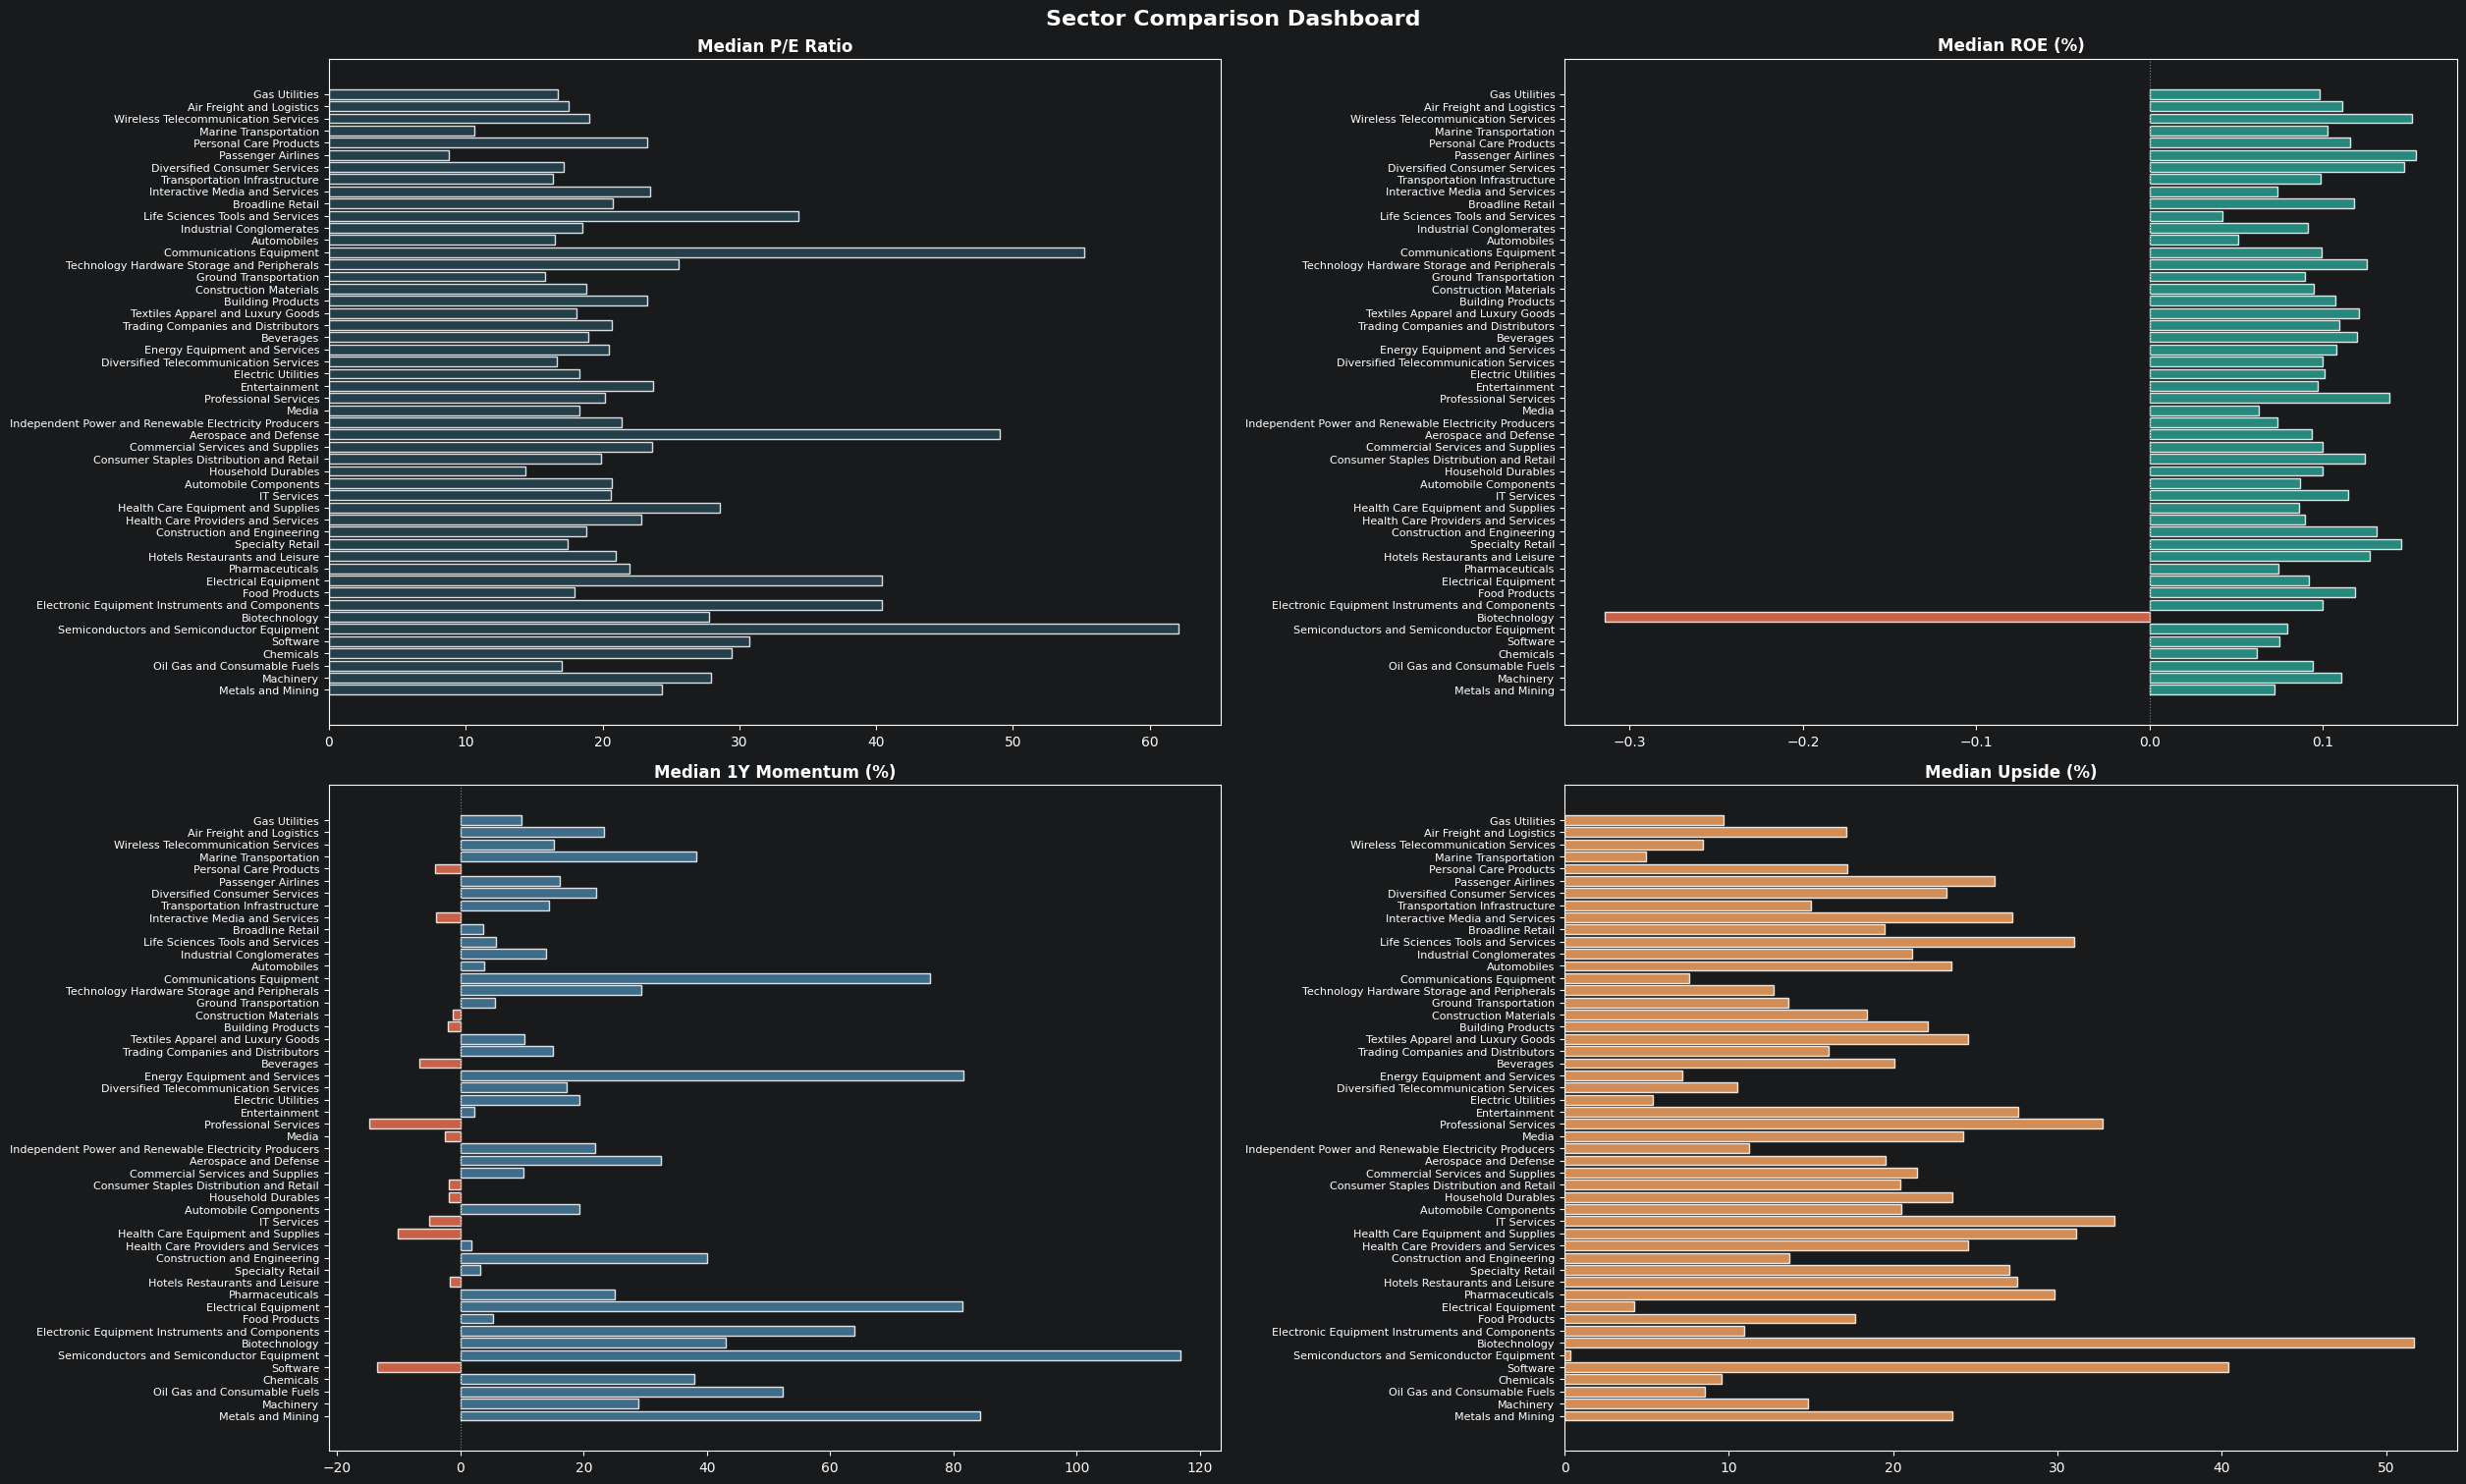

In [34]:
sector_col = next((c for c in ["industry", "sector"] if c in df.columns), None)
if sector_col:
    sector_metrics = df.groupby(sector_col).agg(
        count=("isin", "count"),
        median_pe=("p_e_ratio", "median") if "p_e_ratio" in df.columns else ("isin", "count"),
        median_roe=("roe", "median") if "roe" in df.columns else ("isin", "count"),
        median_momentum=("price_momentum_1y", "median") if "price_momentum_1y" in df.columns else ("isin", "count"),
        median_upside=("upside_potential", "median") if "upside_potential" in df.columns else ("isin", "count"),
    ).sort_values("count", ascending=False)

    print("Sector-Level Summary:")
    display(sector_metrics.head(50))

    # Sector comparison radar-style bar chart
    fig, axes = plt.subplots(2, 2, figsize=(25, 15), constrained_layout=True)
    fig.suptitle("Sector Comparison Dashboard", fontsize=16, fontweight="bold")

    metrics_to_plot = [
        ("median_pe", "Median P/E Ratio", COLORS["primary"]),
        ("median_roe", "Median ROE (%)", COLORS["secondary"]),
        ("median_momentum", "Median 1Y Momentum (%)", COLORS["info"]),
        ("median_upside", "Median Upside (%)", COLORS["light"]),
    ]

    top_sectors = sector_metrics.head(50)
    for idx, (col, title, color) in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        if col in top_sectors.columns:
            vals = top_sectors[col].fillna(0)
            bar_colors = [COLORS["danger"] if v < 0 else color for v in vals]
            ax.barh(top_sectors.index, vals, color=bar_colors, edgecolor="white", alpha=0.85)
            ax.set_title(title, fontweight="bold")
            ax.axvline(0, color="grey", linestyle=":", lw=0.8)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(axis="y", labelsize=8)

    plt.show()

## 25. Core PML Bayesian Modeling (PyMC & ArviZ)

This section implements the next-generation probabilistic models using PyMC for full Bayesian inference. Unlike the baseline models above, these models produce full posterior distributions, allowing for advanced risk analysis and uncertainty quantification.

### 25.1 Kalman Filter Price Targets
Noise-reduced price target signals using state-space modeling.


Capping Kalman observations from 6635 to 1000 for tractability.
Prepared Kalman inputs: 1000 rows, dtype=float64
Running Kalman Filter for AEA001901015 (1000 observations)...


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,3,0.02,511
,1000,1,0.02,511
,1000,0,0.02,511
,1000,0,0.02,511


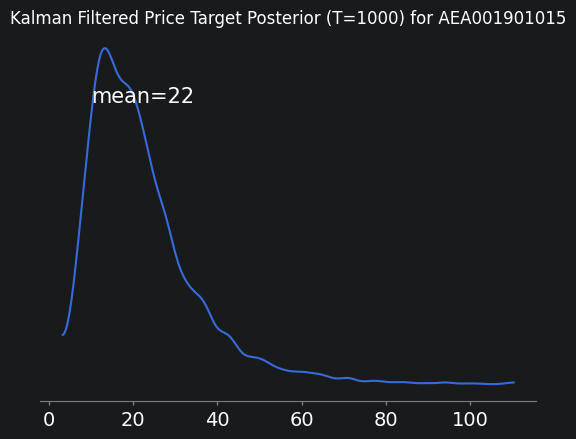

In [35]:
# ── Prepare Kalman Filter inputs (template: EarningsBeatBayesian) ──
# Mirror the dataframe handling used for EarningsBeatBayesian:
#   1. Detect canonical id column (`isin` preferred, fallback to `isin`).
#   2. Drop NaNs and de-duplicate by id so each entity contributes once.
#   3. Cast to explicit dtypes (float64) so PyTensor does NOT infer an
#      int8 default that overflows the `local_subtensor_merge` rewrite
#      (the source of the 6674-out-of-bounds warnings).
#   4. Cap the cross-sectional series length to keep the GaussianRandomWalk
#      tractable.
pt_col = "price_target"
# Fall back to ticker if isin is missing (fix the tautology)
id_col = "isin" if "isin" in df.columns else "ticker"

# Construct the validity mask that was missing
valid_mask = (
        df[id_col].notna()
        & df[pt_col].notna()
        & np.isfinite(pd.to_numeric(df[pt_col], errors="coerce"))
)

cols = list(dict.fromkeys([id_col, "isin", pt_col]))  # preserves order, removes dupes
kf_df = (
    df.loc[valid_mask, cols]
    .drop_duplicates(subset=id_col)
    .sort_values(id_col)
    .reset_index(drop=True)
)

# Bound the observation length — the original 6673 obs triggered an
# int8 overflow inside pytensor.tensor.rewriting.subtensor.merge_two_slices.
MAX_KF_OBS = 1000
if len(kf_df) > MAX_KF_OBS:
    print(f"Capping Kalman observations from {len(kf_df)} to {MAX_KF_OBS} for tractability.")
    kf_df = kf_df.head(MAX_KF_OBS).reset_index(drop=True)

pt_values = np.asarray(kf_df[pt_col].to_numpy(), dtype="float64")
kf_ids = kf_df[id_col].astype(str).to_numpy()

print(f"Prepared Kalman inputs: {len(kf_df)} rows, dtype={pt_values.dtype}")

if len(pt_values) >= 5:
    kf_model = KalmanFilterPriceTarget()
    example_isin = str(kf_df["isin"].iloc[0])
    print(f"Running Kalman Filter for {example_isin} ({len(pt_values)} observations)...")
    kf_idata, kf_modelobj = kf_model.fit(price_targets=pt_values, isin=example_isin, samples=500, tune=500, chains=4,
                                         nuts_sampler="nutpie", idata_kwargs={"log_likelihood": False})

    # Plotting filtered state at the final time index
    # NOTE: arviz>=0.22 delegates HDI computation to arviz_stats, whose `hdi`
    # function no longer accepts the legacy `hdi_prob`/`multimodal` kwargs that
    # `plot_posterior` still forwards. Until that upstream bug is fixed, we
    # disable the HDI overlay (`hdi_prob="hide"`) to avoid the TypeError.
    az.plot_posterior(
        kf_idata,
        var_names=["state"],
        coords={"time": [len(pt_values) - 1]},
        hdi_prob="hide",
    )
    plt.title(f"Kalman Filtered Price Target Posterior (T={len(pt_values)}) for {example_isin}")
    plt.show()
else:
    print(f"Insufficient price target data ({len(pt_values)} obs) — skipping Kalman Filter.")


### 25.5 Accounting Anomaly Detection (Bayesian)
Multi-layered statistical anomaly detection via Mahalanobis distance.


In [36]:
def _plot_forest_topn(idata, var_name, title, top_n=40, dim="isin"):
    """Plot az.plot_forest restricted to top-N coords by posterior mean.

    Avoids matplotlib's 2^23 px size limit when posterior dimension is huge
    (e.g. thousands of ISINs).
    """
    post = idata.posterior[var_name]
    means = post.mean(dim=[d for d in post.dims if d not in (dim,)])
    if dim in means.dims and means.sizes[dim] > top_n:
        top_idx = means.argsort().values[-top_n:]
        top_coords = means[dim].values[top_idx]
        coords = {dim: list(top_coords)}
        n_rows = len(top_coords)
    else:
        coords = None
        n_rows = means.sizes.get(dim, 1) if dim in means.dims else 1
    fig_h = min(0.25 * max(n_rows, 4) + 1.5, 60)
    az.plot_forest(idata, var_names=[var_name], combined=True,
                   coords=coords, figsize=(10, fig_h))
    plt.title(f"{title} (top {n_rows})")
    plt.tight_layout()
    plt.show()


anomaly_bayesian = AccountingAnomalyBayesian(threshold=2.5)

# Multi-category anomaly features verified against DDL
anomaly_feature_cols = [
    "eps_surprise_pct", "eps_adjustment_ratio", "gaap_adj_eps_gap_pct",
    "ebitda_adjustment_ratio", "earnings_quality_score",
    "ni_adjustment_ratio", "cfo_to_net_income", "accounting_quality_score",
    "debt_to_equity", "current_ratio",
]
anomaly_features = [f for f in anomaly_feature_cols if f in df.columns][:10]

if len(anomaly_features) >= 3:
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    feat_vals = scaler.fit_transform(df[anomaly_features].fillna(0).values)

    print(f"Running Bayesian Anomaly Detection using: {anomaly_features}")
    anomaly_idata, anomaly_model = anomaly_bayesian.fit(
        feature_values=feat_vals,
        isins=df["isin"].values,
        feature_names=anomaly_features,
        samples=1000,
        tune=500,
        chains=4,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    # Visualization — limit forest plot to top-N ISINs to avoid huge figures
    _plot_forest_topn(anomaly_idata)


Running Bayesian Anomaly Detection using: ['eps_surprise_pct', 'eps_adjustment_ratio', 'gaap_adj_eps_gap_pct', 'ebitda_adjustment_ratio', 'earnings_quality_score', 'ni_adjustment_ratio', 'cfo_to_net_income', 'accounting_quality_score', 'debt_to_equity', 'current_ratio']


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,805,0.00,2
,1500,604,0.01,3
,1500,782,0.01,3
,1500,506,0.01,5


TypeError: _plot_forest_topn() missing 2 required positional arguments: 'var_name' and 'title'

### 25.6 Credit Risk / Distress Estimation
Bayesian distress estimation with Altman Z-score and Debt-to-Equity signals.


In [ ]:
credit_bayesian = CreditRiskBayesian()
z_col = "altman_z_score"  # DDL: numeric, Quality & Risk category
de_col = "debt_to_equity"  # DDL: numeric, Leverage & Liquidity category

valid_mask = df[z_col].notna() & df[de_col].notna()
cr_df = df[valid_mask]

if len(cr_df) > 0:
    print(f"Running Bayesian Credit Risk Model for {len(cr_df)} stocks...")
    # Pass combined_distress_score as observed distress signal when available
    distress_obs = (cr_df["combined_distress_score"].values / 100
                    if "combined_distress_score" in cr_df.columns else None)

    credit_idata, credit_model = credit_bayesian.fit(
        z_scores=cr_df[z_col].values,
        debt_to_equity=cr_df[de_col].values,
        isin=cr_df["isin"].values,
        sectors=cr_df["sector"].values if "sector" in cr_df.columns else None,
        distress_observed=distress_obs,
        samples=1000,
        tune=500,
        chains=2,
        parameterization="non_centered",
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    _plot_forest_topn(credit_idata, "distress_prob", "Credit Distress Probability Posterior")


### 25.7 Dividend Safety Analysis
Dividend cut probability with FCF coverage and payout ratios.


In [ ]:
div_bayesian = DividendSafetyBayesian()
payout_col = "dividend_payout_ratio"  # DDL: numeric, Dividends category
fcf_cov_col = "fcf_dividend_coverage"  # DDL: numeric, Dividends category

# Filter to dividend-paying stocks only
div_mask = (df[payout_col].notna() & (df[payout_col] > 0) &
            df[fcf_cov_col].notna())
div_df = df[div_mask]

if len(div_df) > 0:
    print(f"Running Bayesian Dividend Safety Model for {len(div_df)} dividend-paying stocks...")
    div_idata, div_model = div_bayesian.fit(
        payout_ratios=div_df[payout_col].values,
        fcf_coverage=div_df[fcf_cov_col].clip(lower=0.01).values,
        isin=div_df["isin"].values,
        samples=1000,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    _plot_forest_topn(div_idata, "cut_prob", "Dividend Cut Probability Posterior")


### 25.8 Earnings Beat Probability
Hierarchical Beta-Binomial model for earnings beat prediction.


In [ ]:
earnings_bayesian = EarningsBeatBayesian()
beats_col = "eps_positive_years"  # DDL: integer — years with positive EPS (proxy for beats)
total_periods = 10  # assume 10-year lookback window for eps_positive_years

if beats_col in df.columns:
    valid_mask = df[beats_col].notna()
    eb_df = df[valid_mask]

    if len(eb_df) > 0:
        print(f"Running Bayesian Earnings Beat Model for {len(eb_df)} stocks...")
        n_total = np.full(len(eb_df), total_periods, dtype="int32")
        n_beats = np.clip(eb_df[beats_col].astype(int).values, 0, total_periods)

        earnings_idata, earnings_model = earnings_bayesian.fit(
            n_beats=n_beats, n_total=n_total, isin=eb_df["isin"].values,
            sectors=eb_df["sector"].values if "sector" in eb_df.columns else None,
            samples=500, tune=500, chains=2, target_accept=0.9,
            parameterization="marginalized",
            nuts_sampler="nutpie",
            idata_kwargs={"log_likelihood": False},
        )

        fig = create_beat_probability_posterior(earnings_idata, title="Earnings Beat Probability Posterior")
        fig.show()


### 25.9 Price Target Achievement
Probability-weighted expected returns with risk adjustment.


In [ ]:
pt_bayesian = PriceTargetAchievement()
upside_col = "upside_potential"  # DDL: numeric, Analyst Sentiment category
disp_col = "price_target_spread_pct"  # DDL: numeric, Analyst Sentiment category

valid_mask = df[upside_col].notna()
pt_df = df[valid_mask]

if len(pt_df) > 0:
    print(f"Running Bayesian Price Target Achievement Model for {len(pt_df)} stocks...")
    disp_values = pt_df[disp_col].fillna(20).values / 100 if disp_col in pt_df.columns \
        else np.full(len(pt_df), 0.2)

    pt_idata, pt_model = pt_bayesian.fit(
        consensus_upside=pt_df[upside_col].values / 100,
        analyst_dispersion=np.clip(disp_values, 0.01, None),
        isin=pt_df["isin"].values,
        samples=1000,
        tune=500,
        chains=2,
        nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    _plot_forest_topn(pt_idata, "achieve_prob", "Price Target Achievement Probability Posterior")


### 25.10 Out-of-sample prediction via `pm.set_data`

Each refactored `fit()` now returns `(idata, model)` and stashes them on
`self.idata_` / `self.model_`, enabling cohort swap-in for forecasting
without rebuilding the model graph.

```python
import pymc as pm

with credit_model:
    pm.set_data({
        "z_score_data": new_z,
        "de_data": new_de,
        "distress_target": np.zeros_like(new_z),
    })
    credit_ppc = pm.sample_posterior_predictive(credit_idata)
```


## 32. Feature Category Coverage Summary

In [ ]:
# Final summary of feature coverage
print("=" * 70)
print("  FEATURE CATEGORY COVERAGE SUMMARY")
print("=" * 70)

total_defined = 0
total_present = 0
for cat, cols in sorted(FEATURE_CATEGORIES.items()):
    present = [c for c in cols if c in df.columns]
    total_defined += len(cols)
    total_present += len(present)
    coverage = len(present) / len(cols) * 100 if cols else 0
    status = "✓" if coverage == 100 else "◐" if coverage >= 50 else "✗"
    print(f"  {status} {cat:30s}  {len(present):3d}/{len(cols):3d} features  ({coverage:5.1f}%)")

print(f"\n  {'TOTAL':30s}  {total_present:3d}/{total_defined:3d} features  "
      f"({total_present / total_defined * 100:.1f}%)")
print(f"\n  Dataset: {df.shape[0]} stocks × {df.shape[1]} columns")
print("=" * 70)